<a href="https://colab.research.google.com/github/wuriley001/gaming-support-llm-finetuning/blob/main/notebooks/gaming_intent_lora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Environment Setup and Base Model Loading

## 1.1 检查 GPU

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


## 1.2 安装项目需要的库

In [ ]:
%pip install -q -U transformers datasets peft trl accelerate bitsandbytes scikit-learn pandas matplotlib

## 1.3 检查库是否安装成功

In [ ]:
import transformers
import datasets
import peft
import trl
import accelerate
import bitsandbytes
import sklearn
import pandas as pd
import matplotlib

print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("peft:", peft.__version__)
print("trl:", trl.__version__)
print("accelerate:", accelerate.__version__)

print("\nEnvironment check passed.")

transformers: 5.18.0
datasets: 5.0.1
peft: 0.21.2
trl: 1.14.1
accelerate: 1.15.0

Environment check passed.


## 1.4 第一次加载 Qwen

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

model.eval()

print("Model loaded successfully.")
print("Model device:", model.device)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Model loaded successfully.
Model device: cuda:0


## 1.5 第一次 inference
```
Gaming support query
        ↓
Tokenizer
        ↓
Qwen2.5-0.5B-Instruct
        ↓
GPU inference
        ↓
Text response
```
现在发生的是：
Qwen 原始模型 → inference

还完全没有：
training fine-tuning LoRA

In [ ]:
messages = [
    {
        "role": "system",
        "content": "You are a helpful assistant for gaming peripheral support."
    },
    {
        "role": "user",
        "content": "My wireless mouse keeps disconnecting while I am gaming. Briefly describe the issue."
    }
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(
    [text],
    return_tensors="pt"
).to(model.device)

with torch.inference_mode():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=64,
        do_sample=False
    )

new_tokens = generated_ids[:, inputs["input_ids"].shape[1]:]

response = tokenizer.batch_decode(
    new_tokens,
    skip_special_tokens=True
)[0]

print(response)

The issue with your wireless mouse disconnecting during gaming could be due to several reasons:

1. **Network Issues**: The network connection might not be stable or strong enough, causing the mouse to disconnect.

2. **Software Conflicts**: There may be conflicts between the operating system and the software that controls the mouse (e


# 2.Task Definition and Label Schema

This project formulates gaming peripheral support as a six-class intent classification task.

Given a user support query, the model must output exactly one of the following intent labels.

| Intent | Definition |
|---|---|
| `device_not_detected` | The computer or configuration software cannot detect or recognize the peripheral device. |
| `wireless_connectivity` | Bluetooth, 2.4 GHz, or other wireless connections are unstable, disconnecting, or unable to connect. |
| `firmware_update` | Problems related to firmware versions, firmware update failures, or the firmware update process. |
| `rgb_lighting` | Problems with RGB lighting, lighting effects, synchronization, brightness, or lighting configuration. |
| `audio_issue` | Problems with headset audio, microphones, sound output/input, volume, or audio quality. |
| `software_configuration` | Problems with configuration software settings such as profiles, DPI, macros, key mappings, or other software-controlled settings. |

**Labeling Rules**

1. `device_not_detected` is used when the device itself cannot be recognized by the computer or configuration software.

2. `wireless_connectivity` is used for Bluetooth or 2.4 GHz pairing, disconnection, or unstable wireless connections.

3. `firmware_update` is reserved for firmware versions and firmware update processes.

4. `rgb_lighting` takes priority when the main problem specifically concerns lighting or RGB behavior.

5. `audio_issue` takes priority when the main symptom concerns microphone, headset audio, sound input/output, or audio quality.

6. `software_configuration` is used when the device is recognized but users cannot correctly configure profiles, DPI, macros, mappings, or other software settings.

In [ ]:
LABELS = [
    "device_not_detected",
    "wireless_connectivity",
    "firmware_update",
    "rgb_lighting",
    "audio_issue",
    "software_configuration",
]

print("Number of classes:", len(LABELS))

for i, label in enumerate(LABELS):
    print(i, label)

Number of classes: 6
0 device_not_detected
1 wireless_connectivity
2 firmware_update
3 rgb_lighting
4 audio_issue
5 software_configuration


# 3.Dataset Creation

We create a small curated Gaming Peripheral Support Intent Dataset covering six support intents.

The dataset is synthetic and manually reviewed for this technical demonstration. It does not contain private customer support records.

In [ ]:
seed_data = [
    # device_not_detected
    {
        "text": "My gaming mouse is plugged in, but the configuration software cannot detect it.",
        "label": "device_not_detected"
    },
    {
        "text": "My keyboard does not appear in the device list even though it is connected by USB.",
        "label": "device_not_detected"
    },
    {
        "text": "The computer does not recognize my headset when I plug it in.",
        "label": "device_not_detected"
    },

    # wireless_connectivity
    {
        "text": "My wireless mouse disconnects every few minutes while I am gaming.",
        "label": "wireless_connectivity"
    },
    {
        "text": "My Bluetooth keyboard cannot pair with my laptop.",
        "label": "wireless_connectivity"
    },
    {
        "text": "The 2.4 GHz connection on my headset keeps dropping randomly.",
        "label": "wireless_connectivity"
    },

    # firmware_update
    {
        "text": "The firmware update fails every time I try to install the latest version.",
        "label": "firmware_update"
    },
    {
        "text": "My mouse firmware updater is stuck at 50 percent.",
        "label": "firmware_update"
    },
    {
        "text": "How can I update the firmware on my gaming keyboard?",
        "label": "firmware_update"
    },

    # rgb_lighting
    {
        "text": "The RGB lighting on my mouse will not sync with my keyboard.",
        "label": "rgb_lighting"
    },
    {
        "text": "My keyboard lighting stays red even after I change the effect.",
        "label": "rgb_lighting"
    },
    {
        "text": "The lights on my headset suddenly stopped working.",
        "label": "rgb_lighting"
    },

    # audio_issue
    {
        "text": "My headset microphone is not picking up my voice.",
        "label": "audio_issue"
    },
    {
        "text": "There is no sound coming from the left side of my headset.",
        "label": "audio_issue"
    },
    {
        "text": "The audio from my gaming headset sounds distorted and crackly.",
        "label": "audio_issue"
    },

    # software_configuration
    {
        "text": "My mouse is detected, but I cannot save my custom DPI profile.",
        "label": "software_configuration"
    },
    {
        "text": "The software recognizes my keyboard, but I cannot remap the macro keys.",
        "label": "software_configuration"
    },
    {
        "text": "My custom gaming profile resets every time I restart the configuration software.",
        "label": "software_configuration"
    },
]

In [ ]:
import pandas as pd

seed_df = pd.DataFrame(seed_data)

seed_df

,text,label
0,"My gaming mouse is plugged in, but the configu...",device_not_detected
1,My keyboard does not appear in the device list...,device_not_detected
2,The computer does not recognize my headset whe...,device_not_detected
3,My wireless mouse disconnects every few minute...,wireless_connectivity
4,My Bluetooth keyboard cannot pair with my laptop.,wireless_connectivity
5,The 2.4 GHz connection on my headset keeps dro...,wireless_connectivity
6,The firmware update fails every time I try to ...,firmware_update
7,My mouse firmware updater is stuck at 50 percent.,firmware_update
8,How can I update the firmware on my gaming key...,firmware_update
9,The RGB lighting on my mouse will not sync wit...,rgb_lighting


In [ ]:
print("Number of samples:", len(seed_df))

Number of samples: 18


In [ ]:
# 这就涉及一个机器学习项目里非常重要的概念： Class Balance；如果类别不平衡，模型可能会在不知道答案的时候就猜数量最多那个
seed_df["label"].value_counts()

label
device_not_detected       3
wireless_connectivity     3
firmware_update           3
rgb_lighting              3
audio_issue               3
software_configuration    3
Name: count, dtype: int64

In [ ]:
# Dataset Validation
print("Missing text:", seed_df["text"].isna().sum())
print("Missing labels:", seed_df["label"].isna().sum())
print("Duplicate texts:", seed_df["text"].duplicated().sum())

Missing text: 0
Missing labels: 0
Duplicate texts: 0


In [ ]:
invalid_labels = set(seed_df["label"]) - set(LABELS)

print("Invalid labels:", invalid_labels)

Invalid labels: set()


注意下面这些句子并不是简单替换：mouse → keyboard

里面其实加入了几个不同场景：
- 配置软件检测不到
- 电脑检测不到
- USB unknown device
- 更新后检测不到
- 设备有电但软件看不到
- 键盘功能正常但配置软件识别不到

这就是我们想要的 diversity。

In [ ]:
device_not_detected_samples = [
    "My mouse suddenly disappeared from the configuration software.",
    "The software says no supported device is connected even though my keyboard is plugged in.",
    "My gaming headset is connected by USB but does not show up on my computer.",
    "The configuration app cannot find my mouse after I restarted the PC.",
    "My keyboard works for typing, but the device software does not recognize it.",
    "The computer shows an unknown USB device instead of my gaming mouse.",
    "My headset does not appear in the list of available devices.",
    "I plugged my keyboard into another USB port, but the software still cannot detect it.",
    "The configuration program stopped recognizing my mouse after an update.",
    "My laptop does not detect my USB gaming headset at all.",
    "The device manager does not show my gaming keyboard when it is connected.",
    "My mouse powers on, but it never appears in the configuration application."
]

In [ ]:
wireless_connectivity_samples = [
    "My mouse keeps losing its 2.4 GHz connection in the middle of games.",
    "The Bluetooth connection to my keyboard drops randomly.",
    "My wireless headset connects successfully but disconnects again after a few minutes.",
    "The USB wireless dongle is plugged in, but my mouse cannot establish a connection.",
    "My keyboard takes several attempts before it pairs over Bluetooth.",
    "The wireless connection becomes unstable when I move the mouse farther from the receiver.",
    "My gaming mouse frequently reconnects while I am playing.",
    "The headset keeps switching between connected and disconnected.",
    "My Bluetooth keyboard was working yesterday but now it refuses to pair.",
    "The 2.4 GHz receiver cannot connect to my wireless keyboard.",
    "My mouse connection freezes for a few seconds and then comes back.",
    "My wireless headset loses connection whenever I start a game."
]

In [ ]:
firmware_update_samples = [
    "The firmware installer says the update failed.",
    "My keyboard firmware update never finishes.",
    "The updater cannot find the latest firmware version for my mouse.",
    "The firmware installation stops halfway through the process.",
    "My headset firmware update gives me an error message.",
    "The device keeps asking me to update its firmware even after I completed the update.",
    "I want to check whether my mouse is running the latest firmware.",
    "The firmware updater closes before the installation is complete.",
    "My keyboard became unresponsive while updating its firmware.",
    "The update tool says my current firmware version is unsupported.",
    "I cannot start the firmware update for my wireless headset.",
    "The firmware update completed, but the device still shows the old version."
]

In [ ]:
rgb_lighting_samples = [
    "The RGB lights on my keyboard do not turn on anymore.",
    "My mouse lighting keeps resetting to the default color.",
    "The lighting effects on my keyboard are not synchronized.",
    "I cannot adjust the brightness of the RGB lights.",
    "Only part of my keyboard lights up when I enable an RGB effect.",
    "My headset lighting does not follow the selected profile.",
    "The RGB effect freezes after a few minutes.",
    "My mouse LEDs stay off even though lighting is enabled.",
    "The keyboard shows the wrong colors for my custom lighting profile.",
    "The lighting animation is not working correctly on my mouse.",
    "My headset RGB keeps returning to the default effect.",
    "The software applies my lighting settings to the keyboard but not the mouse."
]

In [ ]:
audio_issue_samples = [
    "My headset microphone produces a lot of static noise.",
    "The sound from my headset is much quieter than before.",
    "Other players cannot hear me through my microphone.",
    "The right side of my headset has stopped producing sound.",
    "Game audio sounds muffled through my headset.",
    "My microphone volume keeps dropping by itself.",
    "I hear crackling noises whenever I use the headset.",
    "The headset has sound, but the microphone does not work.",
    "My voice sounds distorted when I use the gaming microphone.",
    "There is a noticeable audio delay while I am gaming.",
    "The headset volume is extremely low even when set to maximum.",
    "My microphone keeps cutting out during voice chat."
]

In [ ]:
software_configuration_samples = [
    "I cannot assign a new function to the side buttons on my mouse.",
    "My keyboard profile does not switch when I launch a game.",
    "The software will not save my custom key bindings.",
    "I cannot change the polling rate of my gaming mouse.",
    "My macro disappears after I restart the configuration software.",
    "The application detects my keyboard but will not apply my custom profile.",
    "I want to change the DPI stages on my mouse, but the settings will not save.",
    "My custom button mappings keep returning to their defaults.",
    "The configuration app will not let me create a new gaming profile.",
    "My saved profile does not load when the software starts.",
    "I cannot assign a macro to one of my keyboard keys.",
    "The software recognizes my mouse, but changing sensitivity has no effect."
]

In [ ]:
new_samples = {
    "device_not_detected": device_not_detected_samples,
    "wireless_connectivity": wireless_connectivity_samples,
    "firmware_update": firmware_update_samples,
    "rgb_lighting": rgb_lighting_samples,
    "audio_issue": audio_issue_samples,
    "software_configuration": software_configuration_samples
}

for label, texts in new_samples.items():
    for text in texts:
        seed_data.append({
            "text": text,
            "label": label
        })

seed_df = pd.DataFrame(seed_data)

In [ ]:
print("Number of samples:", len(seed_df))
print()

print(seed_df["label"].value_counts())

Number of samples: 90

label
device_not_detected       15
wireless_connectivity     15
firmware_update           15
rgb_lighting              15
audio_issue               15
software_configuration    15
Name: count, dtype: int64


In [ ]:
print("Missing text:", seed_df["text"].isna().sum())
print("Missing labels:", seed_df["label"].isna().sum())
print("Duplicate texts:", seed_df["text"].duplicated().sum())

invalid_labels = set(seed_df["label"]) - set(LABELS)

print("Invalid labels:", invalid_labels)

Missing text: 0
Missing labels: 0
Duplicate texts: 0
Invalid labels: set()


In [ ]:
base_seed_df = seed_df.copy()

assert len(base_seed_df) == 90
assert (base_seed_df["label"].value_counts() == 15).all()

print("Seed dataset frozen:", len(base_seed_df))

Seed dataset frozen: 90


In [ ]:
import random

RANDOM_SEED = 42
rng = random.Random(RANDOM_SEED)

def generate_samples(spec, n_samples, random_seed=42):
    rng = random.Random(random_seed)

    # Create unique semantic cores first:
    # subject × issue × context
    cores = []

    for subject in spec["subjects"]:
        for issue in spec["issues"]:
            for context in spec["contexts"]:
                cores.append(
                    (subject, issue, context)
                )

    rng.shuffle(cores)

    if len(cores) < n_samples:
        raise ValueError("Not enough unique semantic combinations.")

    selected_cores = cores[:n_samples]

    candidates = []

    for subject, issue, context in selected_cores:

        # Choose only ONE opener for each semantic core
        opener = rng.choice(spec["openers"])

        text = f"{opener}{subject} {issue}{context}."

        text = " ".join(text.split())
        text = text[0].upper() + text[1:]

        candidates.append(text)

    return candidates

In [ ]:
device_not_detected_spec = {
    "openers": [
        "",
        "Recently, ",
        "After restarting my PC, ",
        "Since the last reboot, ",
    ],

    "subjects": [
        "my gaming mouse",
        "my mechanical keyboard",
        "my USB headset",
        "my gaming keypad",
        "my USB gaming mouse",
    ],

    "issues": [
        "is not recognized by the computer",
        "does not appear in the device list",
        "is missing from the configuration software",
        "cannot be detected by the configuration application",
        "shows up as an unknown device",
        "is connected but the software cannot find it",
    ],

    "contexts": [
        "",
        " even though it is plugged in",
        " when I open the configuration software",
        " after reconnecting the USB cable",
        " even though the device has power",
        " after trying another USB port",
    ],
}

wireless_connectivity_spec = {
    "openers": [
        "",
        "Recently, ",
        "While gaming, ",
        "For the past few days, ",
    ],

    "subjects": [
        "my wireless mouse",
        "my Bluetooth keyboard",
        "my wireless headset",
        "my 2.4 GHz gaming mouse",
        "my wireless gaming keyboard",
    ],

    "issues": [
        "keeps disconnecting",
        "randomly loses its connection",
        "fails to pair",
        "connects and disconnects repeatedly",
        "has an unstable wireless connection",
        "cannot establish a reliable connection",
    ],

    "contexts": [
        "",
        " during games",
        " after a few minutes",
        " when using Bluetooth",
        " with the 2.4 GHz receiver",
        " even when the receiver is nearby",
    ],
}

firmware_update_spec = {
    "openers": [
        "",
        "Recently, ",
        "Every time I try, ",
        "After downloading the updater, ",
    ],

    "subjects": [
        "my gaming mouse",
        "my keyboard",
        "my wireless headset",
        "my gaming keypad",
        "my peripheral",
    ],

    "issues": [
        "fails to install the latest firmware",
        "gets stuck during the firmware update",
        "shows an error while updating the firmware",
        "cannot complete the firmware installation",
        "still reports the old firmware version after updating",
        "cannot start the firmware update process",
    ],

    "contexts": [
        "",
        " on my PC",
        " when using the official updater",
        " after reaching about halfway",
        " even after restarting the computer",
        " whenever I try to update it",
    ],
}

rgb_lighting_spec = {
    "openers": [
        "",
        "Recently, ",
        "After starting my computer, ",
        "While using my gaming setup, ",
    ],

    "subjects": [
        "my RGB keyboard",
        "my gaming mouse",
        "my RGB headset",
        "my mechanical keyboard",
        "my gaming peripheral",
    ],

    "issues": [
        "does not display the selected lighting effect",
        "keeps resetting to the default color",
        "has RGB lights that no longer turn on",
        "cannot synchronize its lighting with my other devices",
        "shows the wrong colors",
        "has a lighting effect that freezes",
    ],

    "contexts": [
        "",
        " after I change the profile",
        " in the configuration software",
        " after a few minutes",
        " when I select a custom effect",
        " even though RGB lighting is enabled",
    ],
}

audio_issue_spec = {
    "openers": [
        "",
        "Recently, ",
        "While gaming, ",
        "During voice chat, ",
    ],

    "subjects": [
        "my gaming headset",
        "my headset microphone",
        "my USB headset",
        "my gaming microphone",
        "my wireless headset",
    ],

    "issues": [
        "produces distorted audio",
        "has very low volume",
        "keeps cutting out",
        "produces static noise",
        "does not pick up my voice",
        "only plays sound from one side",
    ],

    "contexts": [
        "",
        " during games",
        " in voice chat",
        " even at maximum volume",
        " after a few minutes of use",
        " whenever I join a call",
    ],
}

software_configuration_spec = {
    "openers": [
        "",
        "Recently, ",
        "After opening the configuration software, ",
        "When configuring my setup, ",
    ],

    "subjects": [
        "my gaming mouse",
        "my mechanical keyboard",
        "my configuration software",
        "my gaming profile",
        "my peripheral software",
    ],

    "issues": [
        "will not save my custom settings",
        "cannot apply my custom profile",
        "keeps resetting my button mappings",
        "will not save my DPI settings",
        "cannot apply my macro configuration",
        "keeps reverting to the default profile",
    ],

    "contexts": [
        "",
        " after restarting the application",
        " when I launch a game",
        " even though the device is detected",
        " after I press save",
        " when the computer restarts",
    ],
}

In [ ]:
augmentation_specs = {
    "device_not_detected": device_not_detected_spec,
    "wireless_connectivity": wireless_connectivity_spec,
    "firmware_update": firmware_update_spec,
    "rgb_lighting": rgb_lighting_spec,
    "audio_issue": audio_issue_spec,
    "software_configuration": software_configuration_spec,
}

augmented_rows = []

for label_index, (label, spec) in enumerate(
    augmentation_specs.items()
):
    generated_texts = generate_samples(
        spec,
        n_samples=85,
        random_seed=42 + label_index
    )

    for text in generated_texts:
        augmented_rows.append({
            "text": text,
            "label": label,
            "source": "synthetic_template"
        })

augmented_df = pd.DataFrame(augmented_rows)

In [ ]:
seed_with_source = base_seed_df.copy()
seed_with_source["source"] = "seed"

full_df = pd.concat(
    [seed_with_source, augmented_df],
    ignore_index=True
)

print("Total samples:", len(full_df))
print()
print(full_df["label"].value_counts())

Total samples: 600

label
device_not_detected       100
wireless_connectivity     100
firmware_update           100
rgb_lighting              100
audio_issue               100
software_configuration    100
Name: count, dtype: int64


In [ ]:
for label in LABELS:
    print("=" * 80)
    print(label)
    print("=" * 80)

    examples = (
        full_df[full_df["label"] == label]
        .sample(5, random_state=42)
    )

    for text in examples["text"]:
        print("-", text)

    print()

device_not_detected
- Since the last reboot, my gaming keypad shows up as an unknown device even though it is plugged in.
- Recently, my USB gaming mouse does not appear in the device list after trying another USB port.
- After restarting my PC, my USB gaming mouse is missing from the configuration software.
- My gaming mouse is missing from the configuration software when I open the configuration software.
- Recently, my USB gaming mouse is not recognized by the computer when I open the configuration software.

wireless_connectivity
- For the past few days, my Bluetooth keyboard fails to pair during games.
- My wireless gaming keyboard connects and disconnects repeatedly after a few minutes.
- Recently, my Bluetooth keyboard keeps disconnecting during games.
- For the past few days, my wireless gaming keyboard fails to pair.
- While gaming, my wireless headset randomly loses its connection after a few minutes.

firmware_update
- Every time I try, my gaming keypad cannot start the firm

In [ ]:
print("Total samples:", len(full_df))
print("Missing text:", full_df["text"].isna().sum())
print("Missing labels:", full_df["label"].isna().sum())
print("Exact duplicate texts:", full_df["text"].duplicated().sum())

invalid_labels = set(full_df["label"]) - set(LABELS)

print("Invalid labels:", invalid_labels)

Total samples: 600
Missing text: 0
Missing labels: 0
Exact duplicate texts: 0
Invalid labels: set()


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(full_df["text"])

similarity_matrix = cosine_similarity(X)

np.fill_diagonal(similarity_matrix, 0)

near_duplicate_pairs = []

threshold = 0.90

for i in range(len(full_df)):
    for j in range(i + 1, len(full_df)):

        if similarity_matrix[i, j] >= threshold:

            near_duplicate_pairs.append(
                (
                    i,
                    j,
                    similarity_matrix[i, j],
                    full_df.iloc[i]["text"],
                    full_df.iloc[j]["text"]
                )
            )

print(
    "Potential near-duplicate pairs:",
    len(near_duplicate_pairs)
)

Potential near-duplicate pairs: 21


In [ ]:
near_duplicate_pairs = sorted(
    near_duplicate_pairs,
    key=lambda x: x[2],
    reverse=True
)

for pair in near_duplicate_pairs[:10]:

    i, j, score, text1, text2 = pair

    print(f"Similarity: {score:.3f}")
    print("A:", text1)
    print("B:", text2)
    print("-" * 80)

Similarity: 0.955
A: Since the last reboot, my USB gaming mouse is missing from the configuration software even though the device has power.
B: Since the last reboot, my gaming mouse is missing from the configuration software even though the device has power.
--------------------------------------------------------------------------------
Similarity: 0.950
A: Recently, my USB gaming mouse is not recognized by the computer after trying another USB port.
B: Recently, my gaming mouse is not recognized by the computer after trying another USB port.
--------------------------------------------------------------------------------
Similarity: 0.935
A: Recently, my gaming mouse is connected but the software cannot find it when I open the configuration software.
B: My USB gaming mouse is connected but the software cannot find it when I open the configuration software.
--------------------------------------------------------------------------------
Similarity: 0.930
A: My gaming mouse is missing

In [ ]:
full_df.to_csv(
    "gaming_support_full_dataset.csv",
    index=False
)

print("Dataset saved.")

Dataset saved.


# 4.划分 Train / Validation / Test
Train → 学习

Validation → 调整 / 检查

Test → 最终一次公平评估

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    full_df,
    test_size=0.20,
    random_state=42,
    stratify=full_df["label"]
)

print("Train:", len(train_df))
print("Temporary:", len(temp_df))

Train: 480
Temporary: 120


In [ ]:
validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

Train: 480
Validation: 60
Test: 60


In [ ]:
print(train_df["label"].value_counts())

label
audio_issue               80
wireless_connectivity     80
firmware_update           80
device_not_detected       80
rgb_lighting              80
software_configuration    80
Name: count, dtype: int64


In [ ]:
print(validation_df["label"].value_counts())

label
wireless_connectivity     10
software_configuration    10
device_not_detected       10
firmware_update           10
audio_issue               10
rgb_lighting              10
Name: count, dtype: int64


In [ ]:
print(test_df["label"].value_counts())

label
rgb_lighting              10
software_configuration    10
device_not_detected       10
audio_issue               10
wireless_connectivity     10
firmware_update           10
Name: count, dtype: int64


In [ ]:
train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [ ]:
train_texts = set(train_df["text"])
validation_texts = set(validation_df["text"])
test_texts = set(test_df["text"])

print(
    "Train ∩ Validation:",
    len(train_texts & validation_texts)
)

print(
    "Train ∩ Test:",
    len(train_texts & test_texts)
)

print(
    "Validation ∩ Test:",
    len(validation_texts & test_texts)
)

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def find_cross_split_similarities(
    df_a,
    df_b,
    threshold=0.90
):
    all_texts = list(df_a["text"]) + list(df_b["text"])

    vectorizer = TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2)
    )

    X = vectorizer.fit_transform(all_texts)

    X_a = X[:len(df_a)]
    X_b = X[len(df_a):]

    similarities = cosine_similarity(X_a, X_b)

    pairs = []

    rows, cols = np.where(similarities >= threshold)

    for i, j in zip(rows, cols):
        pairs.append({
            "similarity": similarities[i, j],
            "text_a": df_a.iloc[i]["text"],
            "label_a": df_a.iloc[i]["label"],
            "text_b": df_b.iloc[j]["text"],
            "label_b": df_b.iloc[j]["label"],
        })

    return sorted(
        pairs,
        key=lambda x: x["similarity"],
        reverse=True
    )

In [ ]:
train_test_similar = find_cross_split_similarities(
    train_df,
    test_df,
    threshold=0.90
)

print(
    "Potential Train-Test near-duplicate pairs:",
    len(train_test_similar)
)

Potential Train-Test near-duplicate pairs: 2


In [ ]:
for pair in train_test_similar[:10]:

    print(
        f"Similarity: {pair['similarity']:.3f}"
    )

    print(
        "TRAIN:",
        pair["text_a"],
        "|",
        pair["label_a"]
    )

    print(
        "TEST:",
        pair["text_b"],
        "|",
        pair["label_b"]
    )

    print("-" * 80)

Similarity: 0.954
TRAIN: Since the last reboot, my gaming mouse is missing from the configuration software even though the device has power. | device_not_detected
TEST: Since the last reboot, my USB gaming mouse is missing from the configuration software even though the device has power. | device_not_detected
--------------------------------------------------------------------------------
Similarity: 0.925
TRAIN: Recently, my gaming headset does not pick up my voice in voice chat. | audio_issue
TEST: Recently, my wireless headset does not pick up my voice in voice chat. | audio_issue
--------------------------------------------------------------------------------


In [ ]:
import os

os.makedirs("data", exist_ok=True)

train_df.to_csv(
    "data/train.csv",
    index=False
)

validation_df.to_csv(
    "data/validation.csv",
    index=False
)

test_df.to_csv(
    "data/test.csv",
    index=False
)

print("Datasets saved.")

Datasets saved.


# 5.构造 Instruction / SFT 格式

In [ ]:
SYSTEM_PROMPT = """You are a gaming peripheral support intent classifier.

Classify each user query into exactly one of the following categories:

device_not_detected
wireless_connectivity
firmware_update
rgb_lighting
audio_issue
software_configuration

Return only the category name. Do not provide explanations."""

In [ ]:
def format_training_example(row):
    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": row["text"]
        },
        {
            "role": "assistant",
            "content": row["label"]
        }
    ]

    formatted_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )

    return formatted_text

In [ ]:
example = format_training_example(
    train_df.iloc[0]
)

print(example)

<|im_start|>system
You are a gaming peripheral support intent classifier.

Classify each user query into exactly one of the following categories:

device_not_detected
wireless_connectivity
firmware_update
rgb_lighting
audio_issue
software_configuration

Return only the category name. Do not provide explanations.<|im_end|>
<|im_start|>user
The right side of my headset has stopped producing sound.<|im_end|>
<|im_start|>assistant
audio_issue<|im_end|>



In [ ]:
train_sft_df = train_df.copy()
validation_sft_df = validation_df.copy()

train_sft_df["text_sft"] = train_sft_df.apply(
    format_training_example,
    axis=1
)

validation_sft_df["text_sft"] = validation_sft_df.apply(
    format_training_example,
    axis=1
)

In [ ]:
sample_rows = train_sft_df.sample(
    5,
    random_state=42
)

for _, row in sample_rows.iterrows():
    print("=" * 100)
    print("ORIGINAL QUERY:")
    print(row["text"])

    print("\nLABEL:")
    print(row["label"])

    print("\nSFT FORMAT:")
    print(row["text_sft"])

    print()

ORIGINAL QUERY:
Recently, my gaming mouse keeps resetting to the default color after I change the profile.

LABEL:
rgb_lighting

SFT FORMAT:
<|im_start|>system
You are a gaming peripheral support intent classifier.

Classify each user query into exactly one of the following categories:

device_not_detected
wireless_connectivity
firmware_update
rgb_lighting
audio_issue
software_configuration

Return only the category name. Do not provide explanations.<|im_end|>
<|im_start|>user
Recently, my gaming mouse keeps resetting to the default color after I change the profile.<|im_end|>
<|im_start|>assistant
rgb_lighting<|im_end|>


ORIGINAL QUERY:
Every time I try, my gaming keypad still reports the old firmware version after updating whenever I try to update it.

LABEL:
firmware_update

SFT FORMAT:
<|im_start|>system
You are a gaming peripheral support intent classifier.

Classify each user query into exactly one of the following categories:

device_not_detected
wireless_connectivity
firmware_u

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_sft_df[["text_sft"]],
    preserve_index=False
)

validation_dataset = Dataset.from_pandas(
    validation_sft_df[["text_sft"]],
    preserve_index=False
)

print(train_dataset)
print(validation_dataset)

Dataset({
    features: ['text_sft'],
    num_rows: 480
})
Dataset({
    features: ['text_sft'],
    num_rows: 60
})


In [ ]:
print(train_dataset[0]["text_sft"])

<|im_start|>system
You are a gaming peripheral support intent classifier.

Classify each user query into exactly one of the following categories:

device_not_detected
wireless_connectivity
firmware_update
rgb_lighting
audio_issue
software_configuration

Return only the category name. Do not provide explanations.<|im_end|>
<|im_start|>user
The right side of my headset has stopped producing sound.<|im_end|>
<|im_start|>assistant
audio_issue<|im_end|>



In [ ]:
token_lengths = []

for text in train_sft_df["text_sft"]:
    tokens = tokenizer(
        text,
        add_special_tokens=False
    )

    token_lengths.append(
        len(tokens["input_ids"])
    )

print("Minimum tokens:", min(token_lengths))
print("Maximum tokens:", max(token_lengths))
print(
    "Average tokens:",
    sum(token_lengths) / len(token_lengths)
)

Minimum tokens: 81
Maximum tokens: 103
Average tokens: 89.8


# 6.建立 Base Model Baseline

In [ ]:
def predict_intent(model, tokenizer, query):
    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": query
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=16,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_tokens = outputs[
        0,
        inputs["input_ids"].shape[1]:
    ]

    prediction = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    return prediction.strip()

In [ ]:
sample_query = test_df.iloc[0]["text"]
sample_label = test_df.iloc[0]["label"]

sample_prediction = predict_intent(
    model,
    tokenizer,
    sample_query
)

print("Query:")
print(sample_query)

print("\nGround truth:")
print(sample_label)

print("\nBase model prediction:")
print(sample_prediction)

Query:
While using my gaming setup, my gaming mouse cannot synchronize its lighting with my other devices after a few minutes.

Ground truth:
rgb_lighting

Base model prediction:
firmware_update


In [ ]:
def normalize_prediction(prediction):
    return prediction.strip().lower()

In [ ]:
from tqdm.auto import tqdm

base_predictions = []
raw_predictions = []

for query in tqdm(
    test_df["text"],
    desc="Base model evaluation"
):
    raw_pred = predict_intent(
        model,
        tokenizer,
        query
    )

    pred = normalize_prediction(raw_pred)

    raw_predictions.append(raw_pred)
    base_predictions.append(pred)

Base model evaluation:   0%|          | 0/60 [00:00<?, ?it/s]

In [ ]:
for i in range(10):
    print("=" * 80)
    print("Query:", test_df.iloc[i]["text"])
    print("Truth:", test_df.iloc[i]["label"])
    print("Raw prediction:", raw_predictions[i])
    print("Normalized:", base_predictions[i])

Query: While using my gaming setup, my gaming mouse cannot synchronize its lighting with my other devices after a few minutes.
Truth: rgb_lighting
Raw prediction: firmware_update
Normalized: firmware_update
Query: My gaming profile cannot apply my macro configuration when I launch a game.
Truth: software_configuration
Raw prediction: firmware_update
Normalized: firmware_update
Query: Recently, my mechanical keyboard is missing from the configuration software after reconnecting the USB cable.
Truth: device_not_detected
Raw prediction: wireless_connectivity
Normalized: wireless_connectivity
Query: During voice chat, my wireless headset only plays sound from one side after a few minutes of use.
Truth: audio_issue
Raw prediction: wireless_connectivity
Normalized: wireless_connectivity
Query: While gaming, my wireless mouse randomly loses its connection during games.
Truth: wireless_connectivity
Raw prediction: wireless_connectivity
Normalized: wireless_connectivity
Query: While using my ga

In [ ]:
valid_predictions = [
    pred in LABELS
    for pred in base_predictions
]

valid_count = sum(valid_predictions)

print(
    "Valid predictions:",
    f"{valid_count}/{len(base_predictions)}"
)

print(
    "Valid output rate:",
    f"{valid_count / len(base_predictions):.2%}"
)

Valid predictions: 59/60
Valid output rate: 98.33%


In [ ]:
invalid_outputs = sorted(
    set(
        pred
        for pred in base_predictions
        if pred not in LABELS
    )
)

print("Invalid outputs:")

for output in invalid_outputs:
    print(repr(output))

Invalid outputs:
'lighting_issue'


In [ ]:
from sklearn.metrics import accuracy_score

base_accuracy = accuracy_score(
    test_df["label"],
    base_predictions
)

print(
    f"Base Accuracy: {base_accuracy:.4f}"
)

print(
    f"Base Accuracy: {base_accuracy:.2%}"
)

Base Accuracy: 0.4167
Base Accuracy: 41.67%


In [ ]:
from sklearn.metrics import f1_score

base_macro_f1 = f1_score(
    test_df["label"],
    base_predictions,
    labels=LABELS,
    average="macro",
    zero_division=0
)

print(
    f"Base Macro F1: {base_macro_f1:.4f}"
)

Base Macro F1: 0.3204


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_df["label"],
        base_predictions,
        labels=LABELS,
        zero_division=0
    )
)

                        precision    recall  f1-score   support

   device_not_detected       0.00      0.00      0.00        10
 wireless_connectivity       0.45      1.00      0.62        10
       firmware_update       0.33      1.00      0.50        10
          rgb_lighting       1.00      0.10      0.18        10
           audio_issue       1.00      0.30      0.46        10
software_configuration       0.33      0.10      0.15        10

             micro avg       0.42      0.42      0.42        60
             macro avg       0.52      0.42      0.32        60
          weighted avg       0.52      0.42      0.32        60



In [ ]:
base_results_df = test_df.copy()

base_results_df["prediction"] = base_predictions
base_results_df["raw_prediction"] = raw_predictions

base_results_df["correct"] = (
    base_results_df["label"]
    ==
    base_results_df["prediction"]
)

base_results_df.head()

,text,label,source,prediction,raw_prediction,correct
0,"While using my gaming setup, my gaming mouse c...",rgb_lighting,synthetic_template,firmware_update,firmware_update,False
1,My gaming profile cannot apply my macro config...,software_configuration,synthetic_template,firmware_update,firmware_update,False
2,"Recently, my mechanical keyboard is missing fr...",device_not_detected,synthetic_template,wireless_connectivity,wireless_connectivity,False
3,"During voice chat, my wireless headset only pl...",audio_issue,synthetic_template,wireless_connectivity,wireless_connectivity,False
4,"While gaming, my wireless mouse randomly loses...",wireless_connectivity,synthetic_template,wireless_connectivity,wireless_connectivity,True


In [ ]:
print(
    "Correct:",
    base_results_df["correct"].sum()
)

print(
    "Incorrect:",
    (~base_results_df["correct"]).sum()
)

Correct: 25
Incorrect: 35


In [ ]:
base_results_df[
    ~base_results_df["correct"]
][
    ["text", "label", "prediction"]
].head(10)

,text,label,prediction
0,"While using my gaming setup, my gaming mouse c...",rgb_lighting,firmware_update
1,My gaming profile cannot apply my macro config...,software_configuration,firmware_update
2,"Recently, my mechanical keyboard is missing fr...",device_not_detected,wireless_connectivity
3,"During voice chat, my wireless headset only pl...",audio_issue,wireless_connectivity
5,"While using my gaming setup, my mechanical key...",rgb_lighting,firmware_update
6,My configuration software keeps resetting my b...,software_configuration,firmware_update
8,"During voice chat, my headset microphone does ...",audio_issue,wireless_connectivity
9,My macro disappears after I restart the config...,software_configuration,firmware_update
10,"Recently, my RGB keyboard has a lighting effec...",rgb_lighting,firmware_update
11,"Recently, my gaming peripheral does not displa...",rgb_lighting,lighting_issue


In [ ]:
import os

os.makedirs(
    "results",
    exist_ok=True
)

base_results_df.to_csv(
    "results/base_predictions.csv",
    index=False
)

print(
    "Saved:",
    "results/base_predictions.csv"
)

Saved: results/base_predictions.csv


In [ ]:
metrics_df = pd.DataFrame([
    {
        "model": "Base Qwen2.5-0.5B-Instruct",
        "accuracy": base_accuracy,
        "macro_f1": base_macro_f1
    }
])

metrics_df

,model,accuracy,macro_f1
0,Base Qwen2.5-0.5B-Instruct,0.416667,0.320367


In [ ]:
metrics_df.to_csv(
    "results/metrics.csv",
    index=False
)

In [ ]:
for i, pred in enumerate(base_predictions):
    if pred not in LABELS:
        print("Index:", i)
        print("Query:", test_df.iloc[i]["text"])
        print("Ground truth:", test_df.iloc[i]["label"])
        print("Raw prediction:", repr(raw_predictions[i]))
        print("Normalized:", repr(pred))

Index: 11
Query: Recently, my gaming peripheral does not display the selected lighting effect.
Ground truth: rgb_lighting
Raw prediction: 'lighting_issue'
Normalized: 'lighting_issue'


# 7.建立统一 Evaluation Function

In [ ]:
def normalize_prediction(prediction):
    return prediction.strip().lower()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm
import pandas as pd


def evaluate_model(
    model,
    tokenizer,
    eval_df,
    model_name="model"
):
    raw_predictions = []
    predictions = []

    for query in tqdm(
        eval_df["text"],
        desc=f"Evaluating {model_name}"
    ):
        raw_pred = predict_intent(
            model,
            tokenizer,
            query
        )

        normalized_pred = normalize_prediction(
            raw_pred
        )

        raw_predictions.append(raw_pred)
        predictions.append(normalized_pred)

    # Metrics
    accuracy = accuracy_score(
        eval_df["label"],
        predictions
    )

    macro_f1 = f1_score(
        eval_df["label"],
        predictions,
        labels=LABELS,
        average="macro",
        zero_division=0
    )

    # Valid output rate
    valid_mask = [
        pred in LABELS
        for pred in predictions
    ]

    valid_count = sum(valid_mask)
    valid_output_rate = valid_count / len(predictions)

    # Detailed results
    results_df = eval_df.copy()

    results_df["prediction"] = predictions
    results_df["raw_prediction"] = raw_predictions

    results_df["correct"] = (
        results_df["label"]
        ==
        results_df["prediction"]
    )

    summary = {
        "model": model_name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "valid_predictions": valid_count,
        "total_predictions": len(predictions),
        "valid_output_rate": valid_output_rate,
    }

    return summary, results_df

In [ ]:
base_summary, base_results_df = evaluate_model(
    model=model,
    tokenizer=tokenizer,
    eval_df=test_df,
    model_name="Base Qwen2.5-0.5B-Instruct"
)

Evaluating Base Qwen2.5-0.5B-Instruct:   0%|          | 0/60 [00:00<?, ?it/s]

In [ ]:
base_summary

{'model': 'Base Qwen2.5-0.5B-Instruct',
 'accuracy': 0.4166666666666667,
 'macro_f1': 0.32036713286713286,
 'valid_predictions': 59,
 'total_predictions': 60,
 'valid_output_rate': 0.9833333333333333}

In [ ]:
print(
    "Accuracy:",
    f"{base_summary['accuracy']:.4f}"
)

print(
    "Macro F1:",
    f"{base_summary['macro_f1']:.4f}"
)

print(
    "Valid outputs:",
    f"{base_summary['valid_predictions']}/"
    f"{base_summary['total_predictions']}"
)

Accuracy: 0.4167
Macro F1: 0.3204
Valid outputs: 59/60


In [ ]:
assert abs(
    base_summary["accuracy"] - base_accuracy
) < 1e-8

assert abs(
    base_summary["macro_f1"] - base_macro_f1
) < 1e-8

print("Evaluation function verified.")

Evaluation function verified.


In [ ]:
base_results_df.to_csv(
    "results/base_predictions.csv",
    index=False
)

In [ ]:
metrics_df = pd.DataFrame([
    {
        "model": base_summary["model"],
        "accuracy": base_summary["accuracy"],
        "macro_f1": base_summary["macro_f1"],
        "valid_output_rate": base_summary[
            "valid_output_rate"
        ]
    }
])

metrics_df

,model,accuracy,macro_f1,valid_output_rate
0,Base Qwen2.5-0.5B-Instruct,0.416667,0.320367,0.983333


In [ ]:
metrics_df.to_csv(
    "results/metrics.csv",
    index=False
)

# 8.配置 LoRA + SFT

In [ ]:
from datasets import Dataset

def build_prompt_completion_dataset(df):
    rows = []

    for _, row in df.iterrows():
        rows.append({
            "prompt": [
                {
                    "role": "system",
                    "content": SYSTEM_PROMPT
                },
                {
                    "role": "user",
                    "content": row["text"]
                }
            ],
            "completion": [
                {
                    "role": "assistant",
                    "content": row["label"]
                }
            ]
        })

    return Dataset.from_list(rows)


train_pc_dataset = build_prompt_completion_dataset(
    train_df
)

validation_pc_dataset = build_prompt_completion_dataset(
    validation_df
)

print(train_pc_dataset)
print(validation_pc_dataset)

Dataset({
    features: ['prompt', 'completion'],
    num_rows: 480
})
Dataset({
    features: ['prompt', 'completion'],
    num_rows: 60
})


In [ ]:
train_pc_dataset[0]

{'prompt': [{'content': 'You are a gaming peripheral support intent classifier.\n\nClassify each user query into exactly one of the following categories:\n\ndevice_not_detected\nwireless_connectivity\nfirmware_update\nrgb_lighting\naudio_issue\nsoftware_configuration\n\nReturn only the category name. Do not provide explanations.',
   'role': 'system'},
  {'content': 'The right side of my headset has stopped producing sound.',
   'role': 'user'}],
 'completion': [{'content': 'audio_issue', 'role': 'assistant'}]}

In [ ]:
import gc
import torch

del model

gc.collect()
torch.cuda.empty_cache()

print(
    "GPU memory allocated:",
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)

GPU memory allocated: 0.93 GB


In [ ]:
from transformers import AutoModelForCausalLM

training_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16
)

training_model = training_model.to("cuda")

print(
    "Training model device:",
    training_model.device
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Training model device: cuda:0


In [ ]:
target_module_names = [
    name
    for name, _ in training_model.named_modules()
    if name.endswith(("q_proj", "v_proj"))
]

print(
    "Matched target modules:",
    len(target_module_names)
)

print("\nFirst few examples:")

for name in target_module_names[:8]:
    print(name)

Matched target modules: 48

First few examples:
model.layers.0.self_attn.q_proj
model.layers.0.self_attn.v_proj
model.layers.1.self_attn.q_proj
model.layers.1.self_attn.v_proj
model.layers.2.self_attn.q_proj
model.layers.2.self_attn.v_proj
model.layers.3.self_attn.q_proj
model.layers.3.self_attn.v_proj


In [ ]:
from peft import LoraConfig, TaskType

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,

    target_modules=[
        "q_proj",
        "v_proj"
    ],

    bias="none",

    task_type=TaskType.CAUSAL_LM
)

print(lora_config)

LoraConfig(task_type=<TaskType.CAUSAL_LM: 'CAUSAL_LM'>, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.21.2', base_model_name_or_path=None, revision=None, inference_mode=False, r=8, target_modules={'v_proj', 'q_proj'}, exclude_modules=None, lora_alpha=16, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, velora_config=None, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, monteclora_config=None, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, kasa_config=None, ensure_weight_tying=False)


In [ ]:
from trl import SFTConfig

training_args = SFTConfig(
    output_dir="./outputs/qwen_lora",

    # Training duration
    num_train_epochs=2,

    # Batch size
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,

    # Optimization
    learning_rate=1e-4,
    optim="adamw_torch",

    # Precision for Tesla T4
    fp16=True,
    bf16=False,

    # Our longest example was only 103 tokens
    max_length=128,

    # Only calculate loss on the answer label
    completion_only_loss=True,

    # Validation
    eval_strategy="epoch",

    # Save one checkpoint per epoch
    save_strategy="epoch",

    # Logging
    logging_steps=10,
    report_to="none",

    # Reproducibility
    seed=42,
    data_seed=42,

    # Keep this small project simple
    gradient_checkpointing=False,
    packing=False,
)

In [ ]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

In [ ]:
%pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [ ]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=training_model,

    args=training_args,

    train_dataset=train_pc_dataset,
    eval_dataset=validation_pc_dataset,

    processing_class=tokenizer,

    peft_config=lora_config
)

Tokenizing train dataset:   0%|          | 0/480 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/480 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/480 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/480 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/60 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/60 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/60 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/60 [00:00<?, ? examples/s]

In [ ]:
trainer.model.print_trainable_parameters()

trainable params: 540,672 || all params: 494,573,440 || trainable%: 0.1093


In [ ]:
print(type(trainer.model))

<class 'peft.peft_model.PeftModelForCausalLM'>


# 9.LoRA Smoke Test

In [ ]:
import gc
import torch

del trainer
del training_model

gc.collect()
torch.cuda.empty_cache()

print(
    "GPU memory allocated:",
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)

GPU memory allocated: 1.86 GB


In [ ]:
smoke_train_dataset = (
    train_pc_dataset
    .shuffle(seed=42)
    .select(range(32))
)

smoke_eval_dataset = (
    validation_pc_dataset
    .shuffle(seed=42)
    .select(range(12))
)

print("Smoke train:", len(smoke_train_dataset))
print("Smoke eval:", len(smoke_eval_dataset))

Smoke train: 32
Smoke eval: 12


In [ ]:
from transformers import AutoModelForCausalLM

smoke_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16
)

smoke_model = smoke_model.to("cuda")

print(
    "Smoke model device:",
    smoke_model.device
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Smoke model device: cuda:0


In [ ]:
from trl import SFTConfig

smoke_args = SFTConfig(
    output_dir="./outputs/smoke_test",

    # Only run a few optimization steps
    max_steps=5,

    # Small batch for safety
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=1,

    # Same core optimization setup
    learning_rate=1e-4,
    optim="adamw_torch",

    # Tesla T4
    fp16=True,
    bf16=False,

    max_length=128,
    completion_only_loss=True,

    # Run validation at the end of the smoke test
    eval_strategy="steps",
    eval_steps=5,

    # No checkpoint needed for a temporary test
    save_strategy="no",

    # Show every step
    logging_steps=1,
    report_to="none",

    seed=42,
    data_seed=42,

    gradient_checkpointing=False,
    packing=False,
)

In [ ]:
from trl import SFTTrainer

smoke_trainer = SFTTrainer(
    model=smoke_model,

    args=smoke_args,

    train_dataset=smoke_train_dataset,
    eval_dataset=smoke_eval_dataset,

    processing_class=tokenizer,

    peft_config=lora_config
)

Tokenizing train dataset:   0%|          | 0/32 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/32 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/32 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/32 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/12 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/12 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/12 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/12 [00:00<?, ? examples/s]

In [ ]:
smoke_trainer.model.print_trainable_parameters()

trainable params: 540,672 || all params: 494,573,440 || trainable%: 0.1093


In [ ]:
smoke_result = smoke_trainer.train()

Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
5,0.317700,0.124321,0.191358,1812.000000,0.948148


In [ ]:
print(smoke_result)

TrainOutput(global_step=5, training_loss=0.38273202776908877, metrics={'train_runtime': 2.7831, 'train_samples_per_second': 7.186, 'train_steps_per_second': 1.797, 'total_flos': 4155022384128.0, 'train_loss': 0.38273202776908877, 'epoch': 0.625})


In [ ]:
smoke_trainer.state.log_history

for log in smoke_trainer.state.log_history:
    print(log)

{'loss': 0.31308919191360474, 'grad_norm': nan, 'learning_rate': 0.0001, 'entropy': 0.14226363599300385, 'num_tokens': 365.0, 'mean_token_accuracy': 0.9047619104385376, 'epoch': 0.125, 'step': 1}
{'loss': 0.7289110422134399, 'grad_norm': 10.15201473236084, 'learning_rate': 0.0001, 'entropy': 0.2044539898633957, 'num_tokens': 733.0, 'mean_token_accuracy': 0.7894737124443054, 'epoch': 0.25, 'step': 2}
{'loss': 0.48164868354797363, 'grad_norm': 5.255441188812256, 'learning_rate': 8e-05, 'entropy': 0.15055781602859497, 'num_tokens': 1090.0, 'mean_token_accuracy': 0.9047619104385376, 'epoch': 0.375, 'step': 3}
{'loss': 0.0723111629486084, 'grad_norm': 2.4668917655944824, 'learning_rate': 6e-05, 'entropy': 0.18197107315063477, 'num_tokens': 1436.0, 'mean_token_accuracy': 1.0, 'epoch': 0.5, 'step': 4}
{'loss': 0.317700058221817, 'grad_norm': 3.682962417602539, 'learning_rate': 4e-05, 'entropy': 0.18651773035526276, 'num_tokens': 1812.0, 'mean_token_accuracy': 0.9047619104385376, 'epoch': 0.62

In [ ]:
import math

loss_values = [
    log["loss"]
    for log in smoke_trainer.state.log_history
    if "loss" in log
]

print("Training losses:", loss_values)

has_nan = any(
    math.isnan(loss)
    for loss in loss_values
)

print("NaN detected:", has_nan)

Training losses: [0.31308919191360474, 0.7289110422134399, 0.48164868354797363, 0.0723111629486084, 0.317700058221817]
NaN detected: False


In [ ]:
peak_memory_gb = (
    torch.cuda.max_memory_allocated()
    / 1024**3
)

print(
    f"Peak allocated GPU memory: "
    f"{peak_memory_gb:.2f} GB"
)

Peak allocated GPU memory: 3.86 GB


In [ ]:
del smoke_trainer
del smoke_model
del smoke_result

gc.collect()
torch.cuda.empty_cache()

print("Smoke test model cleared.")

Smoke test model cleared.


# 10.完成 LoRA SFT

In [ ]:
import gc
import torch

try:
    del smoke_trainer
except:
    pass

try:
    del smoke_model
except:
    pass

try:
    del smoke_result
except:
    pass

gc.collect()
torch.cuda.empty_cache()

print(
    "GPU memory allocated:",
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)

GPU memory allocated: 1.87 GB


In [ ]:
from transformers import AutoModelForCausalLM

formal_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16
)

formal_model = formal_model.to("cuda")

print("Formal training model device:", formal_model.device)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Formal training model device: cuda:0


In [ ]:
from trl import SFTConfig

formal_training_args = SFTConfig(
    output_dir="./outputs/qwen_lora",

    # Formal training
    num_train_epochs=2,

    # Batch configuration
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,

    # Optimization
    learning_rate=1e-4,
    optim="adamw_torch",

    # Tesla T4
    fp16=True,
    bf16=False,

    # Dataset
    max_length=128,
    completion_only_loss=True,

    # Evaluate and save after each epoch
    eval_strategy="epoch",
    save_strategy="epoch",

    # Logging
    logging_steps=5,
    report_to="none",

    # Reproducibility
    seed=42,
    data_seed=42,

    # Keep the experiment lightweight
    gradient_checkpointing=False,
    packing=False,
)

In [ ]:
from trl import SFTTrainer

formal_trainer = SFTTrainer(
    model=formal_model,

    args=formal_training_args,

    train_dataset=train_pc_dataset,
    eval_dataset=validation_pc_dataset,

    processing_class=tokenizer,

    peft_config=lora_config
)

Tokenizing train dataset:   0%|          | 0/480 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/480 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/480 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/480 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/60 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/60 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/60 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/60 [00:00<?, ? examples/s]

In [ ]:
formal_trainer.model.print_trainable_parameters()

trainable params: 540,672 || all params: 494,573,440 || trainable%: 0.1093


In [ ]:
torch.cuda.reset_peak_memory_stats()

In [ ]:
formal_train_result = formal_trainer.train()

Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.092045,0.066074,0.120186,43104.000000,0.977247
2,0.032644,0.044376,0.088047,86208.000000,0.993421


In [ ]:
print(formal_train_result)

TrainOutput(global_step=60, training_loss=0.08475768019755682, metrics={'train_runtime': 28.9818, 'train_samples_per_second': 33.124, 'train_steps_per_second': 2.07, 'total_flos': 196997955686400.0, 'train_loss': 0.08475768019755682, 'epoch': 2.0})


In [ ]:
for log in formal_trainer.state.log_history:
    print(log)

{'loss': 0.2945996284484863, 'grad_norm': 1.9856325387954712, 'learning_rate': 9.333333333333334e-05, 'entropy': 0.21757228225469588, 'num_tokens': 7172.0, 'mean_token_accuracy': 0.9163234174251557, 'epoch': 0.16666666666666666, 'step': 5}
{'loss': 0.1578806757926941, 'grad_norm': 0.6070837378501892, 'learning_rate': 8.5e-05, 'entropy': 0.17132973298430443, 'num_tokens': 14387.0, 'mean_token_accuracy': 0.9613738834857941, 'epoch': 0.3333333333333333, 'step': 10}
{'loss': 0.09861940741539002, 'grad_norm': 1.3942729234695435, 'learning_rate': 7.666666666666667e-05, 'entropy': 0.1956180825829506, 'num_tokens': 21583.0, 'mean_token_accuracy': 0.9714328169822692, 'epoch': 0.5, 'step': 15}
{'loss': 0.07975306510925292, 'grad_norm': 1.4749515056610107, 'learning_rate': 6.833333333333333e-05, 'entropy': 0.16820939555764197, 'num_tokens': 28779.0, 'mean_token_accuracy': 0.9769743263721467, 'epoch': 0.6666666666666666, 'step': 20}
{'loss': 0.0598009467124939, 'grad_norm': 0.7244612574577332, 'le

In [ ]:
import math

formal_losses = [
    log["loss"]
    for log in formal_trainer.state.log_history
    if "loss" in log
]

print("Training losses:")
print(formal_losses)

has_nan_loss = any(
    math.isnan(loss)
    for loss in formal_losses
)

print("NaN loss detected:", has_nan_loss)

Training losses:
[0.2945996284484863, 0.1578806757926941, 0.09861940741539002, 0.07975306510925292, 0.0598009467124939, 0.09204535484313965, 0.0651143729686737, 0.0463462769985199, 0.042835140228271486, 0.026372873783111574, 0.02108088433742523, 0.03264353573322296]
NaN loss detected: False


In [ ]:
formal_peak_memory_gb = (
    torch.cuda.max_memory_allocated()
    / 1024**3
)

print(
    f"Formal training peak GPU memory: "
    f"{formal_peak_memory_gb:.2f} GB"
)

Formal training peak GPU memory: 4.32 GB


In [ ]:
FINAL_ADAPTER_DIR = "./outputs/qwen_lora/final_adapter"

formal_trainer.save_model(
    FINAL_ADAPTER_DIR
)

tokenizer.save_pretrained(
    FINAL_ADAPTER_DIR
)

print(
    "Final LoRA adapter saved to:",
    FINAL_ADAPTER_DIR
)

Final LoRA adapter saved to: ./outputs/qwen_lora/final_adapter


In [ ]:
import os

for filename in os.listdir(FINAL_ADAPTER_DIR):
    print(filename)

adapter_config.json
chat_template.jinja
adapter_model.safetensors
tokenizer.json
README.md
training_args.bin
tokenizer_config.json


In [ ]:
del formal_trainer
del formal_model
del formal_train_result

gc.collect()
torch.cuda.empty_cache()

print("Training model cleared.")

Training model cleared.


In [ ]:
base_for_lora = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16
)

base_for_lora = base_for_lora.to("cuda")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
from peft import PeftModel

lora_model = PeftModel.from_pretrained(
    base_for_lora,
    FINAL_ADAPTER_DIR
)

lora_model.eval()

print(type(lora_model))

<class 'peft.peft_model.PeftModelForCausalLM'>


In [ ]:
validation_query = validation_df.iloc[0]["text"]
validation_label = validation_df.iloc[0]["label"]

validation_prediction = predict_intent(
    lora_model,
    tokenizer,
    validation_query
)

print("Query:")
print(validation_query)

print("\nGround truth:")
print(validation_label)

print("\nLoRA prediction:")
print(validation_prediction)

Query:
My keyboard takes several attempts before it pairs over Bluetooth.

Ground truth:
wireless_connectivity

LoRA prediction:
wireless_connectivity


# 11.正式评估 Fine-tuned LoRA Model

In [ ]:
lora_summary, lora_results_df = evaluate_model(
    model=lora_model,
    tokenizer=tokenizer,
    eval_df=test_df,
    model_name="LoRA Fine-tuned Qwen2.5-0.5B-Instruct"
)

Evaluating LoRA Fine-tuned Qwen2.5-0.5B-Instruct:   0%|          | 0/60 [00:00<?, ?it/s]

In [ ]:
lora_summary

{'model': 'LoRA Fine-tuned Qwen2.5-0.5B-Instruct',
 'accuracy': 0.9166666666666666,
 'macro_f1': 0.9233475101896155,
 'valid_predictions': 59,
 'total_predictions': 60,
 'valid_output_rate': 0.9833333333333333}

In [ ]:
print(
    f"LoRA Accuracy: "
    f"{lora_summary['accuracy']:.4f} "
    f"({lora_summary['accuracy']:.2%})"
)

print(
    f"LoRA Macro F1: "
    f"{lora_summary['macro_f1']:.4f}"
)

print(
    f"Valid outputs: "
    f"{lora_summary['valid_predictions']}/"
    f"{lora_summary['total_predictions']}"
)

print(
    f"Valid output rate: "
    f"{lora_summary['valid_output_rate']:.2%}"
)

LoRA Accuracy: 0.9167 (91.67%)
LoRA Macro F1: 0.9233
Valid outputs: 59/60
Valid output rate: 98.33%


In [ ]:
print(
    "Correct:",
    lora_results_df["correct"].sum()
)

print(
    "Incorrect:",
    (~lora_results_df["correct"]).sum()
)

Correct: 55
Incorrect: 5


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_df["label"],
        lora_results_df["prediction"],
        labels=LABELS,
        zero_division=0
    )
)

                        precision    recall  f1-score   support

   device_not_detected       0.89      0.80      0.84        10
 wireless_connectivity       0.90      0.90      0.90        10
       firmware_update       1.00      1.00      1.00        10
          rgb_lighting       1.00      1.00      1.00        10
           audio_issue       1.00      0.80      0.89        10
software_configuration       0.83      1.00      0.91        10

             micro avg       0.93      0.92      0.92        60
             macro avg       0.94      0.92      0.92        60
          weighted avg       0.94      0.92      0.92        60



In [ ]:
invalid_lora_outputs = sorted(
    set(
        pred
        for pred in lora_results_df["prediction"]
        if pred not in LABELS
    )
)

print(
    "Invalid LoRA outputs:",
    invalid_lora_outputs
)

Invalid LoRA outputs: ['voice_issue']


In [ ]:
comparison_df = pd.DataFrame([
    {
        "model": "Base Qwen2.5-0.5B-Instruct",
        "accuracy": base_summary["accuracy"],
        "macro_f1": base_summary["macro_f1"],
        "valid_output_rate": base_summary[
            "valid_output_rate"
        ]
    },
    {
        "model": "LoRA Fine-tuned Qwen2.5-0.5B-Instruct",
        "accuracy": lora_summary["accuracy"],
        "macro_f1": lora_summary["macro_f1"],
        "valid_output_rate": lora_summary[
            "valid_output_rate"
        ]
    }
])

comparison_df

,model,accuracy,macro_f1,valid_output_rate
0,Base Qwen2.5-0.5B-Instruct,0.416667,0.320367,0.983333
1,LoRA Fine-tuned Qwen2.5-0.5B-Instruct,0.916667,0.923348,0.983333


In [ ]:
accuracy_improvement = (
    lora_summary["accuracy"]
    -
    base_summary["accuracy"]
)

f1_improvement = (
    lora_summary["macro_f1"]
    -
    base_summary["macro_f1"]
)

print(
    f"Accuracy improvement: "
    f"{accuracy_improvement:+.4f}"
)

print(
    f"Accuracy percentage-point improvement: "
    f"{accuracy_improvement * 100:+.2f} pp"
)

print(
    f"Macro F1 improvement: "
    f"{f1_improvement:+.4f}"
)

Accuracy improvement: +0.5000
Accuracy percentage-point improvement: +50.00 pp
Macro F1 improvement: +0.6030


In [ ]:
comparison_errors_df = pd.DataFrame({
    "text": test_df["text"],
    "label": test_df["label"],
    "base_prediction": base_results_df["prediction"],
    "lora_prediction": lora_results_df["prediction"]
})

comparison_errors_df["base_correct"] = (
    comparison_errors_df["label"]
    ==
    comparison_errors_df["base_prediction"]
)

comparison_errors_df["lora_correct"] = (
    comparison_errors_df["label"]
    ==
    comparison_errors_df["lora_prediction"]
)

In [ ]:
fixed_by_lora = comparison_errors_df[
    (~comparison_errors_df["base_correct"])
    &
    (comparison_errors_df["lora_correct"])
]

print(
    "Base errors fixed by LoRA:",
    len(fixed_by_lora)
)

fixed_by_lora.head(10)

Base errors fixed by LoRA: 31


,text,label,base_prediction,lora_prediction,base_correct,lora_correct
0,"While using my gaming setup, my gaming mouse c...",rgb_lighting,firmware_update,rgb_lighting,False,True
1,My gaming profile cannot apply my macro config...,software_configuration,firmware_update,software_configuration,False,True
2,"Recently, my mechanical keyboard is missing fr...",device_not_detected,wireless_connectivity,device_not_detected,False,True
3,"During voice chat, my wireless headset only pl...",audio_issue,wireless_connectivity,audio_issue,False,True
5,"While using my gaming setup, my mechanical key...",rgb_lighting,firmware_update,rgb_lighting,False,True
6,My configuration software keeps resetting my b...,software_configuration,firmware_update,software_configuration,False,True
8,"During voice chat, my headset microphone does ...",audio_issue,wireless_connectivity,audio_issue,False,True
9,My macro disappears after I restart the config...,software_configuration,firmware_update,software_configuration,False,True
10,"Recently, my RGB keyboard has a lighting effec...",rgb_lighting,firmware_update,rgb_lighting,False,True
11,"Recently, my gaming peripheral does not displa...",rgb_lighting,lighting_issue,rgb_lighting,False,True


In [ ]:
regressed_after_lora = comparison_errors_df[
    (comparison_errors_df["base_correct"])
    &
    (~comparison_errors_df["lora_correct"])
]

print(
    "Base-correct cases broken by LoRA:",
    len(regressed_after_lora)
)

regressed_after_lora.head(10)

Base-correct cases broken by LoRA: 1


,text,label,base_prediction,lora_prediction,base_correct,lora_correct
55,My 2.4 GHz gaming mouse fails to pair with the...,wireless_connectivity,wireless_connectivity,device_not_detected,True,False


In [ ]:
lora_results_df.to_csv(
    "results/lora_predictions.csv",
    index=False
)

comparison_df.to_csv(
    "results/metrics.csv",
    index=False
)

comparison_errors_df.to_csv(
    "results/base_vs_lora_predictions.csv",
    index=False
)

print("LoRA evaluation results saved.")

LoRA evaluation results saved.


# 12.Inference Latency Benchmark

In [ ]:
benchmark_df = test_df.sample(
    n=30,
    random_state=42
).reset_index(drop=True)

benchmark_queries = benchmark_df["text"].tolist()

print("Benchmark queries:", len(benchmark_queries))

Benchmark queries: 30


In [ ]:
import time
import numpy as np
import torch


def benchmark_latency(
    model,
    tokenizer,
    queries,
    warmup_queries=5
):
    model.eval()

    # -------------------------
    # Warm-up
    # -------------------------
    for query in queries[:warmup_queries]:
        _ = predict_intent(
            model,
            tokenizer,
            query
        )

    torch.cuda.synchronize()

    # -------------------------
    # Timed inference
    # -------------------------
    latencies_ms = []

    for query in queries:
        torch.cuda.synchronize()

        start = time.perf_counter()

        _ = predict_intent(
            model,
            tokenizer,
            query
        )

        torch.cuda.synchronize()

        end = time.perf_counter()

        latency_ms = (
            end - start
        ) * 1000

        latencies_ms.append(
            latency_ms
        )

    results = {
        "avg_latency_ms": np.mean(latencies_ms),
        "median_latency_ms": np.median(latencies_ms),
        "std_latency_ms": np.std(latencies_ms),
        "min_latency_ms": np.min(latencies_ms),
        "max_latency_ms": np.max(latencies_ms),
    }

    return results, latencies_ms

In [ ]:
lora_latency_summary, lora_latencies = (
    benchmark_latency(
        model=lora_model,
        tokenizer=tokenizer,
        queries=benchmark_queries
    )
)

print("LoRA latency benchmark")

for key, value in lora_latency_summary.items():
    print(
        f"{key}: {value:.2f} ms"
    )

LoRA latency benchmark
avg_latency_ms: 295.85 ms
median_latency_ms: 271.57 ms
std_latency_ms: 91.65 ms
min_latency_ms: 181.21 ms
max_latency_ms: 602.88 ms


In [ ]:
lora_avg_latency_ms = (
    lora_latency_summary["avg_latency_ms"]
)

print(
    f"LoRA average latency: "
    f"{lora_avg_latency_ms:.2f} ms/query"
)

LoRA average latency: 295.85 ms/query


In [ ]:
import gc

del lora_model
del base_for_lora

gc.collect()
torch.cuda.empty_cache()

print("LoRA model cleared.")

LoRA model cleared.


In [ ]:
from transformers import AutoModelForCausalLM

base_benchmark_model = (
    AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        dtype=torch.float16
    )
)

base_benchmark_model = (
    base_benchmark_model.to("cuda")
)

base_benchmark_model.eval()

print(
    "Base benchmark model device:",
    base_benchmark_model.device
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Base benchmark model device: cuda:0


In [ ]:
base_latency_summary, base_latencies = (
    benchmark_latency(
        model=base_benchmark_model,
        tokenizer=tokenizer,
        queries=benchmark_queries
    )
)

print("Base latency benchmark")

for key, value in base_latency_summary.items():
    print(
        f"{key}: {value:.2f} ms"
    )

Base latency benchmark
avg_latency_ms: 362.86 ms
median_latency_ms: 342.07 ms
std_latency_ms: 138.39 ms
min_latency_ms: 172.03 ms
max_latency_ms: 675.45 ms


In [ ]:
base_avg_latency_ms = (
    base_latency_summary["avg_latency_ms"]
)

print(
    f"Base average latency: "
    f"{base_avg_latency_ms:.2f} ms/query"
)

Base average latency: 362.86 ms/query


In [ ]:
latency_comparison_df = pd.DataFrame([
    {
        "model": "Base Qwen2.5-0.5B-Instruct",
        "avg_latency_ms": base_latency_summary[
            "avg_latency_ms"
        ],
        "median_latency_ms": base_latency_summary[
            "median_latency_ms"
        ],
        "std_latency_ms": base_latency_summary[
            "std_latency_ms"
        ],
    },
    {
        "model": "LoRA Fine-tuned Qwen2.5-0.5B-Instruct",
        "avg_latency_ms": lora_latency_summary[
            "avg_latency_ms"
        ],
        "median_latency_ms": lora_latency_summary[
            "median_latency_ms"
        ],
        "std_latency_ms": lora_latency_summary[
            "std_latency_ms"
        ],
    }
])

latency_comparison_df

,model,avg_latency_ms,median_latency_ms,std_latency_ms
0,Base Qwen2.5-0.5B-Instruct,362.855448,342.074604,138.390640
1,LoRA Fine-tuned Qwen2.5-0.5B-Instruct,295.845467,271.569623,91.651347


In [ ]:
latency_difference_ms = (
    lora_avg_latency_ms
    -
    base_avg_latency_ms
)

latency_change_pct = (
    latency_difference_ms
    /
    base_avg_latency_ms
    * 100
)

print(
    f"LoRA latency difference: "
    f"{latency_difference_ms:+.2f} ms"
)

print(
    f"LoRA latency change: "
    f"{latency_change_pct:+.2f}%"
)

LoRA latency difference: -67.01 ms
LoRA latency change: -18.47%


In [ ]:
metrics_df = pd.DataFrame([
    {
        "model": "Base Qwen2.5-0.5B-Instruct",
        "accuracy": base_summary["accuracy"],
        "macro_f1": base_summary["macro_f1"],
        "valid_output_rate": base_summary[
            "valid_output_rate"
        ],
        "avg_latency_ms": base_avg_latency_ms,
    },
    {
        "model": "LoRA Fine-tuned Qwen2.5-0.5B-Instruct",
        "accuracy": lora_summary["accuracy"],
        "macro_f1": lora_summary["macro_f1"],
        "valid_output_rate": lora_summary[
            "valid_output_rate"
        ],
        "avg_latency_ms": lora_avg_latency_ms,
    },
])

metrics_df

,model,accuracy,macro_f1,valid_output_rate,avg_latency_ms
0,Base Qwen2.5-0.5B-Instruct,0.416667,0.320367,0.983333,362.855448
1,LoRA Fine-tuned Qwen2.5-0.5B-Instruct,0.916667,0.923348,0.983333,295.845467


In [ ]:
metrics_df.to_csv(
    "results/metrics.csv",
    index=False
)

# 13.Peak GPU Memory Benchmark

In [ ]:
import gc
import torch


def benchmark_gpu_memory(
    model,
    tokenizer,
    queries,
    warmup_queries=5
):
    model.eval()

    # -------------------------
    # Warm-up
    # -------------------------
    for query in queries[:warmup_queries]:
        _ = predict_intent(
            model,
            tokenizer,
            query
        )

    torch.cuda.synchronize()

    # Remove unused cached blocks
    gc.collect()
    torch.cuda.empty_cache()

    # Memory occupied by model tensors before benchmark
    baseline_allocated_gb = (
        torch.cuda.memory_allocated()
        / 1024**3
    )

    baseline_reserved_gb = (
        torch.cuda.memory_reserved()
        / 1024**3
    )

    # Reset peak statistics AFTER model loading/warm-up
    torch.cuda.reset_peak_memory_stats()

    # -------------------------
    # Inference benchmark
    # -------------------------
    for query in queries:
        _ = predict_intent(
            model,
            tokenizer,
            query
        )

    torch.cuda.synchronize()

    peak_allocated_gb = (
        torch.cuda.max_memory_allocated()
        / 1024**3
    )

    peak_reserved_gb = (
        torch.cuda.max_memory_reserved()
        / 1024**3
    )

    return {
        "baseline_allocated_gb": baseline_allocated_gb,
        "baseline_reserved_gb": baseline_reserved_gb,
        "peak_allocated_gb": peak_allocated_gb,
        "peak_reserved_gb": peak_reserved_gb,
    }

In [ ]:
base_memory_summary = benchmark_gpu_memory(
    model=base_benchmark_model,
    tokenizer=tokenizer,
    queries=benchmark_queries
)

print("Base GPU memory benchmark")

for key, value in base_memory_summary.items():
    print(f"{key}: {value:.3f} GB")

Base GPU memory benchmark
baseline_allocated_gb: 2.795 GB
baseline_reserved_gb: 2.889 GB
peak_allocated_gb: 2.800 GB
peak_reserved_gb: 2.895 GB


In [ ]:
del base_benchmark_model

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print(
    "GPU allocated after Base cleanup:",
    f"{torch.cuda.memory_allocated() / 1024**3:.3f} GB"
)

GPU allocated after Base cleanup: 1.867 GB


In [ ]:
from transformers import AutoModelForCausalLM
from peft import PeftModel

base_for_memory = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16
)

base_for_memory = base_for_memory.to("cuda")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
lora_memory_model = PeftModel.from_pretrained(
    base_for_memory,
    FINAL_ADAPTER_DIR
)

lora_memory_model.eval()

print(type(lora_memory_model))

<class 'peft.peft_model.PeftModelForCausalLM'>


In [ ]:
lora_memory_summary = benchmark_gpu_memory(
    model=lora_memory_model,
    tokenizer=tokenizer,
    queries=benchmark_queries
)

print("LoRA GPU memory benchmark")

for key, value in lora_memory_summary.items():
    print(f"{key}: {value:.3f} GB")

LoRA GPU memory benchmark
baseline_allocated_gb: 2.797 GB
baseline_reserved_gb: 2.891 GB
peak_allocated_gb: 2.802 GB
peak_reserved_gb: 2.896 GB


In [ ]:
memory_comparison_df = pd.DataFrame([
    {
        "model": "Base Qwen2.5-0.5B-Instruct",
        "baseline_allocated_gb":
            base_memory_summary["baseline_allocated_gb"],
        "peak_gpu_memory_gb":
            base_memory_summary["peak_allocated_gb"],
        "peak_reserved_gb":
            base_memory_summary["peak_reserved_gb"],
    },
    {
        "model": "LoRA Fine-tuned Qwen2.5-0.5B-Instruct",
        "baseline_allocated_gb":
            lora_memory_summary["baseline_allocated_gb"],
        "peak_gpu_memory_gb":
            lora_memory_summary["peak_allocated_gb"],
        "peak_reserved_gb":
            lora_memory_summary["peak_reserved_gb"],
    }
])

memory_comparison_df

,model,baseline_allocated_gb,peak_gpu_memory_gb,peak_reserved_gb
0,Base Qwen2.5-0.5B-Instruct,2.795262,2.799516,2.894531
1,LoRA Fine-tuned Qwen2.5-0.5B-Instruct,2.797276,2.801530,2.896484


In [ ]:
base_peak_memory_gb = (
    base_memory_summary["peak_allocated_gb"]
)

lora_peak_memory_gb = (
    lora_memory_summary["peak_allocated_gb"]
)

memory_difference_gb = (
    lora_peak_memory_gb
    -
    base_peak_memory_gb
)

memory_change_pct = (
    memory_difference_gb
    /
    base_peak_memory_gb
    * 100
)

print(
    f"LoRA peak memory difference: "
    f"{memory_difference_gb:+.3f} GB"
)

print(
    f"LoRA peak memory change: "
    f"{memory_change_pct:+.2f}%"
)

LoRA peak memory difference: +0.002 GB
LoRA peak memory change: +0.07%


In [ ]:
metrics_df = pd.DataFrame([
    {
        "model": "Base Qwen2.5-0.5B-Instruct",
        "accuracy": base_summary["accuracy"],
        "macro_f1": base_summary["macro_f1"],
        "valid_output_rate":
            base_summary["valid_output_rate"],
        "avg_latency_ms":
            base_avg_latency_ms,
        "peak_gpu_memory_gb":
            base_peak_memory_gb,
    },
    {
        "model": "LoRA Fine-tuned Qwen2.5-0.5B-Instruct",
        "accuracy": lora_summary["accuracy"],
        "macro_f1": lora_summary["macro_f1"],
        "valid_output_rate":
            lora_summary["valid_output_rate"],
        "avg_latency_ms":
            lora_avg_latency_ms,
        "peak_gpu_memory_gb":
            lora_peak_memory_gb,
    },
])

metrics_df

,model,accuracy,macro_f1,valid_output_rate,avg_latency_ms,peak_gpu_memory_gb
0,Base Qwen2.5-0.5B-Instruct,0.416667,0.320367,0.983333,362.855448,2.799516
1,LoRA Fine-tuned Qwen2.5-0.5B-Instruct,0.916667,0.923348,0.983333,295.845467,2.801530


In [ ]:
metrics_df.to_csv(
    "results/metrics.csv",
    index=False
)

# 14.LoRA + 4-bit Quantized Inference

In [ ]:
import gc
import torch

try:
    del lora_memory_model
except:
    pass

try:
    del base_for_memory
except:
    pass

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print(
    "GPU allocated after cleanup:",
    f"{torch.cuda.memory_allocated() / 1024**3:.3f} GB"
)

GPU allocated after cleanup: 1.867 GB


In [ ]:
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,

    # Quantization format
    bnb_4bit_quant_type="nf4",

    # T4-friendly compute type
    bnb_4bit_compute_dtype=torch.float16,

    # Keep the experiment simple
    bnb_4bit_use_double_quant=False
)

print(bnb_config)

BitsAndBytesConfig {
  "_load_in_4bit": true,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "float16",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": false,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": true,
  "load_in_8bit": false,
  "quant_method": "bitsandbytes"
}



In [ ]:
from transformers import AutoModelForCausalLM

quantized_base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,

    quantization_config=bnb_config,

    device_map="auto",

    dtype=torch.float16
)

print(
    "4-bit model loaded."
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

4-bit model loaded.


In [ ]:
print(
    "is_loaded_in_4bit:",
    getattr(
        quantized_base_model,
        "is_loaded_in_4bit",
        False
    )
)

is_loaded_in_4bit: True


In [ ]:
print(
    "Quantization config:"
)

print(
    quantized_base_model.config.quantization_config
)

Quantization config:
BitsAndBytesConfig {
  "_load_in_4bit": true,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "float16",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": false,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": true,
  "load_in_8bit": false,
  "quant_method": "bitsandbytes"
}



In [ ]:
quantized_footprint_gb = (
    quantized_base_model.get_memory_footprint()
    / 1024**3
)

print(
    f"4-bit base model footprint: "
    f"{quantized_footprint_gb:.3f} GB"
)

4-bit base model footprint: 0.420 GB


In [ ]:
from peft import PeftModel

lora_4bit_model = PeftModel.from_pretrained(
    quantized_base_model,
    FINAL_ADAPTER_DIR
)

lora_4bit_model.eval()

print(type(lora_4bit_model))

<class 'peft.peft_model.PeftModelForCausalLM'>


In [ ]:
print(
    "4-bit base inside PEFT:",
    getattr(
        lora_4bit_model.base_model.model,
        "is_loaded_in_4bit",
        False
    )
)

4-bit base inside PEFT: True


In [ ]:
query = validation_df.iloc[0]["text"]
truth = validation_df.iloc[0]["label"]

pred = predict_intent(
    lora_4bit_model,
    tokenizer,
    query
)

print("Query:")
print(query)

print("\nGround truth:")
print(truth)

print("\n4-bit LoRA prediction:")
print(pred)

Query:
My keyboard takes several attempts before it pairs over Bluetooth.

Ground truth:
wireless_connectivity

4-bit LoRA prediction:
wireless_connectivity


In [ ]:
quantized_summary, quantized_results_df = evaluate_model(
    model=lora_4bit_model,
    tokenizer=tokenizer,
    eval_df=test_df,
    model_name="LoRA + 4-bit Qwen2.5-0.5B-Instruct"
)

Evaluating LoRA + 4-bit Qwen2.5-0.5B-Instruct:   0%|          | 0/60 [00:00<?, ?it/s]

In [ ]:
quantized_summary

{'model': 'LoRA + 4-bit Qwen2.5-0.5B-Instruct',
 'accuracy': 0.9833333333333333,
 'macro_f1': 0.9912280701754387,
 'valid_predictions': 59,
 'total_predictions': 60,
 'valid_output_rate': 0.9833333333333333}

In [ ]:
print(
    f"4-bit Accuracy: "
    f"{quantized_summary['accuracy']:.4f} "
    f"({quantized_summary['accuracy']:.2%})"
)

print(
    f"4-bit Macro F1: "
    f"{quantized_summary['macro_f1']:.4f}"
)

print(
    f"Valid outputs: "
    f"{quantized_summary['valid_predictions']}/"
    f"{quantized_summary['total_predictions']}"
)

4-bit Accuracy: 0.9833 (98.33%)
4-bit Macro F1: 0.9912
Valid outputs: 59/60


In [ ]:
quant_accuracy_change = (
    quantized_summary["accuracy"]
    -
    lora_summary["accuracy"]
)

quant_f1_change = (
    quantized_summary["macro_f1"]
    -
    lora_summary["macro_f1"]
)

print(
    f"4-bit accuracy change vs FP16 LoRA: "
    f"{quant_accuracy_change * 100:+.2f} pp"
)

print(
    f"4-bit Macro F1 change vs FP16 LoRA: "
    f"{quant_f1_change:+.4f}"
)

4-bit accuracy change vs FP16 LoRA: +6.67 pp
4-bit Macro F1 change vs FP16 LoRA: +0.0679


In [ ]:
invalid_4bit_outputs = sorted(
    set(
        pred
        for pred in quantized_results_df["prediction"]
        if pred not in LABELS
    )
)

print(
    "Invalid 4-bit outputs:",
    invalid_4bit_outputs
)

Invalid 4-bit outputs: ['keyboard_colorization']


In [ ]:
quantized_latency_summary, quantized_latencies = (
    benchmark_latency(
        model=lora_4bit_model,
        tokenizer=tokenizer,
        queries=benchmark_queries
    )
)

print("4-bit latency benchmark")

for key, value in quantized_latency_summary.items():
    print(
        f"{key}: {value:.2f} ms"
    )

4-bit latency benchmark
avg_latency_ms: 386.98 ms
median_latency_ms: 364.89 ms
std_latency_ms: 118.20 ms
min_latency_ms: 239.94 ms
max_latency_ms: 672.38 ms


In [ ]:
quantized_avg_latency_ms = (
    quantized_latency_summary["avg_latency_ms"]
)

In [ ]:
quantized_memory_summary = benchmark_gpu_memory(
    model=lora_4bit_model,
    tokenizer=tokenizer,
    queries=benchmark_queries
)

print("4-bit GPU memory benchmark")

for key, value in quantized_memory_summary.items():
    print(
        f"{key}: {value:.3f} GB"
    )

4-bit GPU memory benchmark
baseline_allocated_gb: 2.312 GB
baseline_reserved_gb: 2.352 GB
peak_allocated_gb: 2.324 GB
peak_reserved_gb: 2.357 GB


In [ ]:
quantized_peak_memory_gb = (
    quantized_memory_summary[
        "peak_allocated_gb"
    ]
)

memory_reduction_gb = (
    lora_peak_memory_gb
    -
    quantized_peak_memory_gb
)

memory_reduction_pct = (
    memory_reduction_gb
    /
    lora_peak_memory_gb
    * 100
)

print(
    f"4-bit memory reduction vs FP16 LoRA: "
    f"{memory_reduction_gb:.3f} GB"
)

print(
    f"4-bit memory reduction: "
    f"{memory_reduction_pct:.2f}%"
)

4-bit memory reduction vs FP16 LoRA: 0.478 GB
4-bit memory reduction: 17.06%


In [ ]:
metrics_df = pd.DataFrame([
    {
        "model": "Base Qwen2.5-0.5B-Instruct",
        "accuracy": base_summary["accuracy"],
        "macro_f1": base_summary["macro_f1"],
        "valid_output_rate":
            base_summary["valid_output_rate"],
        "avg_latency_ms":
            base_avg_latency_ms,
        "peak_gpu_memory_gb":
            base_peak_memory_gb,
    },

    {
        "model": "LoRA Fine-tuned Qwen2.5-0.5B-Instruct",
        "accuracy": lora_summary["accuracy"],
        "macro_f1": lora_summary["macro_f1"],
        "valid_output_rate":
            lora_summary["valid_output_rate"],
        "avg_latency_ms":
            lora_avg_latency_ms,
        "peak_gpu_memory_gb":
            lora_peak_memory_gb,
    },

    {
        "model": "LoRA + 4-bit Qwen2.5-0.5B-Instruct",
        "accuracy": quantized_summary["accuracy"],
        "macro_f1": quantized_summary["macro_f1"],
        "valid_output_rate":
            quantized_summary["valid_output_rate"],
        "avg_latency_ms":
            quantized_avg_latency_ms,
        "peak_gpu_memory_gb":
            quantized_peak_memory_gb,
    },
])

metrics_df

,model,accuracy,macro_f1,valid_output_rate,avg_latency_ms,peak_gpu_memory_gb
0,Base Qwen2.5-0.5B-Instruct,0.416667,0.320367,0.983333,362.855448,2.799516
1,LoRA Fine-tuned Qwen2.5-0.5B-Instruct,0.916667,0.923348,0.983333,295.845467,2.801530
2,LoRA + 4-bit Qwen2.5-0.5B-Instruct,0.983333,0.991228,0.983333,386.984476,2.323626


In [ ]:
metrics_df.to_csv(
    "results/metrics.csv",
    index=False
)

quantized_results_df.to_csv(
    "results/quantized_predictions.csv",
    index=False
)

# 15.Error Analysis

In [ ]:
lora_errors_df = lora_results_df[
    ~lora_results_df["correct"]
][
    [
        "text",
        "label",
        "prediction",
        "raw_prediction"
    ]
].reset_index(drop=True)

print(
    "Number of LoRA errors:",
    len(lora_errors_df)
)

lora_errors_df

Number of LoRA errors: 5


,text,label,prediction,raw_prediction
0,"Recently, my wireless headset does not pick up...",audio_issue,voice_issue,voice_issue
1,"While gaming, my wireless headset only plays s...",audio_issue,wireless_connectivity,wireless_connectivity
2,"My keyboard works for typing, but the device s...",device_not_detected,software_configuration,software_configuration
3,The configuration app cannot find my mouse aft...,device_not_detected,software_configuration,software_configuration
4,My 2.4 GHz gaming mouse fails to pair with the...,wireless_connectivity,device_not_detected,device_not_detected


In [ ]:
for i, row in lora_errors_df.iterrows():

    print("=" * 90)
    print(f"Error {i + 1}")

    print("Query:")
    print(row["text"])

    print("\nGround truth:")
    print(row["label"])

    print("\nPrediction:")
    print(row["prediction"])

    print("\nRaw prediction:")
    print(repr(row["raw_prediction"]))

Error 1
Query:
Recently, my wireless headset does not pick up my voice in voice chat.

Ground truth:
audio_issue

Prediction:
voice_issue

Raw prediction:
'voice_issue'
Error 2
Query:
While gaming, my wireless headset only plays sound from one side during games.

Ground truth:
audio_issue

Prediction:
wireless_connectivity

Raw prediction:
'wireless_connectivity'
Error 3
Query:
My keyboard works for typing, but the device software does not recognize it.

Ground truth:
device_not_detected

Prediction:
software_configuration

Raw prediction:
'software_configuration'
Error 4
Query:
The configuration app cannot find my mouse after I restarted the PC.

Ground truth:
device_not_detected

Prediction:
software_configuration

Raw prediction:
'software_configuration'
Error 5
Query:
My 2.4 GHz gaming mouse fails to pair with the 2.4 GHz receiver.

Ground truth:
wireless_connectivity

Prediction:
device_not_detected

Raw prediction:
'device_not_detected'


In [ ]:
error_patterns = (
    lora_errors_df
    .groupby(
        ["label", "prediction"]
    )
    .size()
    .reset_index(name="count")
    .sort_values(
        "count",
        ascending=False
    )
)

error_patterns

,label,prediction,count
2,device_not_detected,software_configuration,2
0,audio_issue,voice_issue,1
1,audio_issue,wireless_connectivity,1
3,wireless_connectivity,device_not_detected,1


In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

lora_cm = confusion_matrix(
    test_df["label"],
    lora_results_df["prediction"],
    labels=LABELS
)

lora_cm_df = pd.DataFrame(
    lora_cm,
    index=LABELS,
    columns=LABELS
)

lora_cm_df

,device_not_detected,wireless_connectivity,firmware_update,rgb_lighting,audio_issue,software_configuration
device_not_detected,8,0,0,0,0,2
wireless_connectivity,1,9,0,0,0,0
firmware_update,0,0,10,0,0,0
rgb_lighting,0,0,0,10,0,0
audio_issue,0,1,0,0,8,0
software_configuration,0,0,0,0,0,10


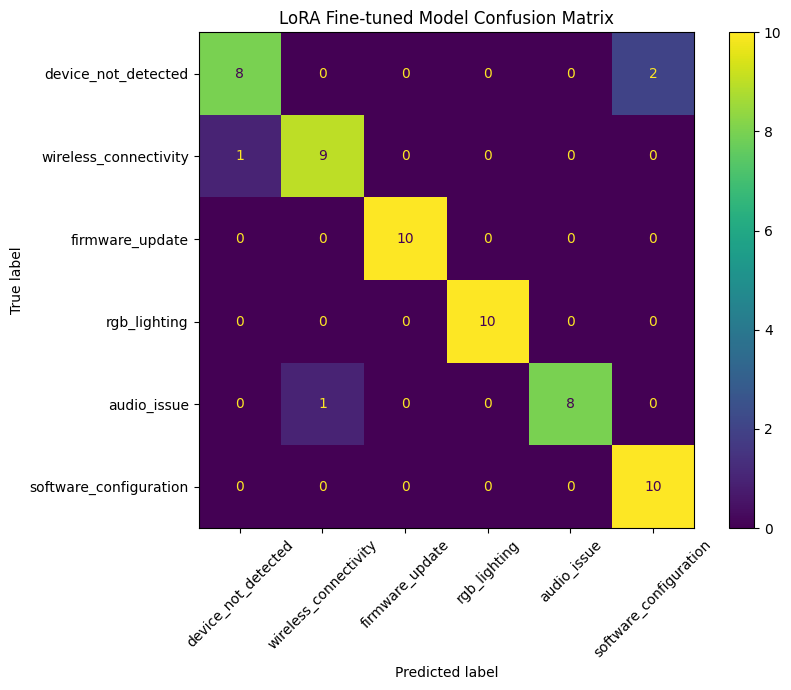

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(
    figsize=(9, 7)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=lora_cm,
    display_labels=LABELS
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title(
    "LoRA Fine-tuned Model Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    "results/lora_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
quantization_comparison_df = pd.DataFrame({
    "text": test_df["text"],
    "label": test_df["label"],
    "fp16_prediction":
        lora_results_df["prediction"],
    "quantized_prediction":
        quantized_results_df["prediction"],
})

In [ ]:
quantization_comparison_df["fp16_correct"] = (
    quantization_comparison_df["label"]
    ==
    quantization_comparison_df[
        "fp16_prediction"
    ]
)

quantization_comparison_df["quantized_correct"] = (
    quantization_comparison_df["label"]
    ==
    quantization_comparison_df[
        "quantized_prediction"
    ]
)

In [ ]:
changed_after_quantization = (
    quantization_comparison_df[
        quantization_comparison_df[
            "fp16_prediction"
        ]
        !=
        quantization_comparison_df[
            "quantized_prediction"
        ]
    ]
)

print(
    "Predictions changed after quantization:",
    len(changed_after_quantization)
)

changed_after_quantization

Predictions changed after quantization: 6


,text,label,fp16_prediction,quantized_prediction,fp16_correct,quantized_correct
5,"While using my gaming setup, my mechanical key...",rgb_lighting,rgb_lighting,keyboard_colorization,True,False
19,"Recently, my wireless headset does not pick up...",audio_issue,voice_issue,audio_issue,False,True
47,"While gaming, my wireless headset only plays s...",audio_issue,wireless_connectivity,audio_issue,False,True
52,"My keyboard works for typing, but the device s...",device_not_detected,software_configuration,device_not_detected,False,True
54,The configuration app cannot find my mouse aft...,device_not_detected,software_configuration,device_not_detected,False,True
55,My 2.4 GHz gaming mouse fails to pair with the...,wireless_connectivity,device_not_detected,wireless_connectivity,False,True


In [ ]:
fixed_by_quantization = (
    quantization_comparison_df[
        (~quantization_comparison_df["fp16_correct"])
        &
        (
            quantization_comparison_df[
                "quantized_correct"
            ]
        )
    ]
)

print(
    "FP16 errors fixed by 4-bit:",
    len(fixed_by_quantization)
)

fixed_by_quantization

FP16 errors fixed by 4-bit: 5


,text,label,fp16_prediction,quantized_prediction,fp16_correct,quantized_correct
19,"Recently, my wireless headset does not pick up...",audio_issue,voice_issue,audio_issue,False,True
47,"While gaming, my wireless headset only plays s...",audio_issue,wireless_connectivity,audio_issue,False,True
52,"My keyboard works for typing, but the device s...",device_not_detected,software_configuration,device_not_detected,False,True
54,The configuration app cannot find my mouse aft...,device_not_detected,software_configuration,device_not_detected,False,True
55,My 2.4 GHz gaming mouse fails to pair with the...,wireless_connectivity,device_not_detected,wireless_connectivity,False,True


In [ ]:
broken_by_quantization = (
    quantization_comparison_df[
        (
            quantization_comparison_df[
                "fp16_correct"
            ]
        )
        &
        (
            ~quantization_comparison_df[
                "quantized_correct"
            ]
        )
    ]
)

print(
    "FP16-correct cases broken by 4-bit:",
    len(broken_by_quantization)
)

broken_by_quantization

FP16-correct cases broken by 4-bit: 1


,text,label,fp16_prediction,quantized_prediction,fp16_correct,quantized_correct
5,"While using my gaming setup, my mechanical key...",rgb_lighting,rgb_lighting,keyboard_colorization,True,False


In [ ]:
quantized_errors_df = (
    quantized_results_df[
        ~quantized_results_df["correct"]
    ][
        [
            "text",
            "label",
            "prediction",
            "raw_prediction"
        ]
    ]
)

quantized_errors_df

,text,label,prediction,raw_prediction
5,"While using my gaming setup, my mechanical key...",rgb_lighting,keyboard_colorization,keyboard_colorization


In [ ]:
lora_errors_df.to_csv(
    "results/lora_errors.csv",
    index=False
)

quantized_errors_df.to_csv(
    "results/quantized_errors.csv",
    index=False
)

changed_after_quantization.to_csv(
    "results/quantization_prediction_changes.csv",
    index=False
)

# 16.最终实验结果文件生成

In [ ]:
final_metrics_df = pd.DataFrame([
    {
        "model": "Base Qwen2.5-0.5B-Instruct",
        "precision": "FP16",
        "accuracy": base_summary["accuracy"],
        "macro_f1": base_summary["macro_f1"],
        "valid_output_rate": base_summary["valid_output_rate"],
        "avg_latency_ms": base_avg_latency_ms,
        "peak_gpu_memory_gb": base_peak_memory_gb,
    },

    {
        "model": "LoRA Fine-tuned Qwen2.5-0.5B-Instruct",
        "precision": "FP16",
        "accuracy": lora_summary["accuracy"],
        "macro_f1": lora_summary["macro_f1"],
        "valid_output_rate": lora_summary["valid_output_rate"],
        "avg_latency_ms": lora_avg_latency_ms,
        "peak_gpu_memory_gb": lora_peak_memory_gb,
    },

    {
        "model": "LoRA Fine-tuned Qwen2.5-0.5B-Instruct",
        "precision": "4-bit",
        "accuracy": quantized_summary["accuracy"],
        "macro_f1": quantized_summary["macro_f1"],
        "valid_output_rate": quantized_summary["valid_output_rate"],
        "avg_latency_ms": quantized_avg_latency_ms,
        "peak_gpu_memory_gb": quantized_peak_memory_gb,
    }
])

final_metrics_df

,model,precision,accuracy,macro_f1,valid_output_rate,avg_latency_ms,peak_gpu_memory_gb
0,Base Qwen2.5-0.5B-Instruct,FP16,0.416667,0.320367,0.983333,362.855448,2.799516
1,LoRA Fine-tuned Qwen2.5-0.5B-Instruct,FP16,0.916667,0.923348,0.983333,295.845467,2.801530
2,LoRA Fine-tuned Qwen2.5-0.5B-Instruct,4-bit,0.983333,0.991228,0.983333,386.984476,2.323626


In [ ]:
final_metrics_df.to_csv(
    "results/metrics.csv",
    index=False
)

print("Saved results/metrics.csv")

Saved results/metrics.csv


In [ ]:
display_metrics_df = final_metrics_df.copy()

display_metrics_df["accuracy"] = (
    display_metrics_df["accuracy"] * 100
).round(2)

display_metrics_df["macro_f1"] = (
    display_metrics_df["macro_f1"]
).round(4)

display_metrics_df["valid_output_rate"] = (
    display_metrics_df["valid_output_rate"] * 100
).round(2)

display_metrics_df["avg_latency_ms"] = (
    display_metrics_df["avg_latency_ms"]
).round(2)

display_metrics_df["peak_gpu_memory_gb"] = (
    display_metrics_df["peak_gpu_memory_gb"]
).round(3)

display_metrics_df

,model,precision,accuracy,macro_f1,valid_output_rate,avg_latency_ms,peak_gpu_memory_gb
0,Base Qwen2.5-0.5B-Instruct,FP16,41.67,0.3204,98.33,362.86,2.800
1,LoRA Fine-tuned Qwen2.5-0.5B-Instruct,FP16,91.67,0.9233,98.33,295.85,2.802
2,LoRA Fine-tuned Qwen2.5-0.5B-Instruct,4-bit,98.33,0.9912,98.33,386.98,2.324


In [ ]:
plot_df = pd.DataFrame({
    "Model": [
        "Base FP16",
        "LoRA FP16",
        "LoRA 4-bit"
    ],
    "Accuracy": [
        base_summary["accuracy"],
        lora_summary["accuracy"],
        quantized_summary["accuracy"],
    ],
    "Macro F1": [
        base_summary["macro_f1"],
        lora_summary["macro_f1"],
        quantized_summary["macro_f1"],
    ]
})

plot_df

,Model,Accuracy,Macro F1
0,Base FP16,0.416667,0.320367
1,LoRA FP16,0.916667,0.923348
2,LoRA 4-bit,0.983333,0.991228


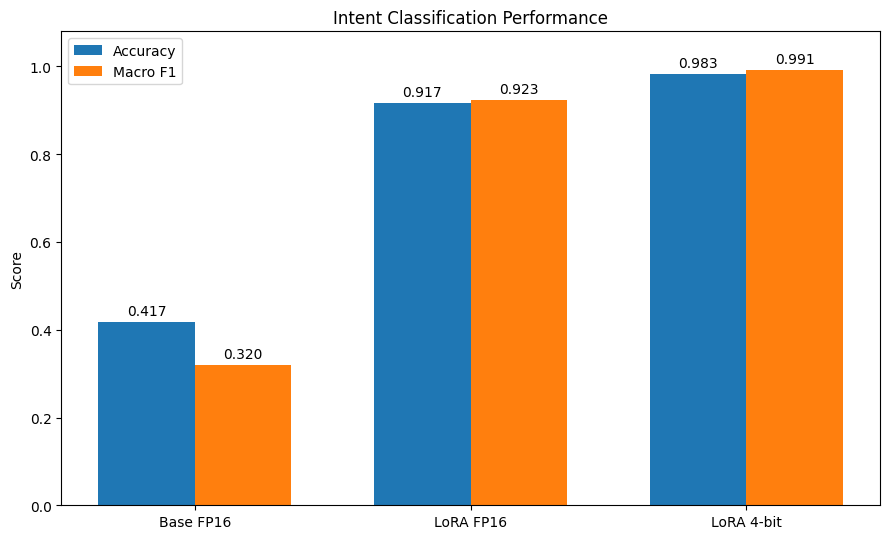

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = plot_df["Model"]

accuracy_values = plot_df["Accuracy"]
f1_values = plot_df["Macro F1"]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))

bars1 = ax.bar(
    x - width / 2,
    accuracy_values,
    width,
    label="Accuracy"
)

bars2 = ax.bar(
    x + width / 2,
    f1_values,
    width,
    label="Macro F1"
)

ax.set_ylabel("Score")
ax.set_title(
    "Intent Classification Performance"
)

ax.set_xticks(x)
ax.set_xticklabels(models)

ax.set_ylim(0, 1.08)

ax.legend()

ax.bar_label(
    bars1,
    fmt="%.3f",
    padding=3
)

ax.bar_label(
    bars2,
    fmt="%.3f",
    padding=3
)

plt.tight_layout()

plt.savefig(
    "results/model_performance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
lora_predictions_for_cm = [
    pred if pred in LABELS else "invalid_output"
    for pred in lora_results_df["prediction"]
]

In [ ]:
CM_LABELS = LABELS + [
    "invalid_output"
]

In [ ]:
from sklearn.metrics import confusion_matrix

lora_cm_final = confusion_matrix(
    test_df["label"],
    lora_predictions_for_cm,
    labels=CM_LABELS
)

In [ ]:
lora_cm_display = (
    lora_cm_final[:len(LABELS), :]
)

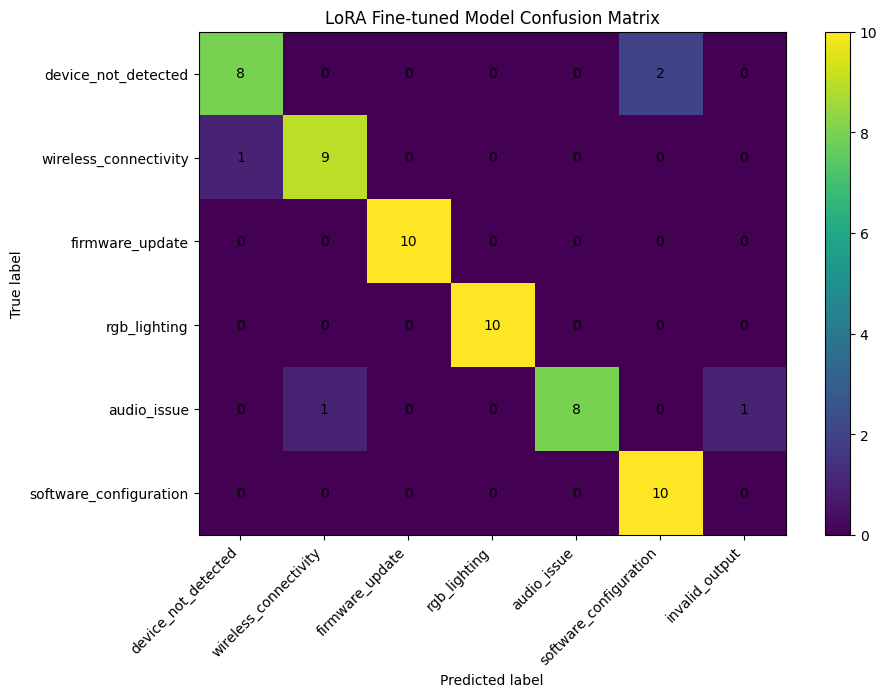

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(10, 7)
)

im = ax.imshow(
    lora_cm_display
)

ax.set_xticks(
    np.arange(len(CM_LABELS))
)

ax.set_yticks(
    np.arange(len(LABELS))
)

ax.set_xticklabels(
    CM_LABELS,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    LABELS
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_title(
    "LoRA Fine-tuned Model Confusion Matrix"
)

for i in range(len(LABELS)):
    for j in range(len(CM_LABELS)):
        ax.text(
            j,
            i,
            lora_cm_display[i, j],
            ha="center",
            va="center"
        )

fig.colorbar(
    im,
    ax=ax
)

plt.tight_layout()

plt.savefig(
    "results/lora_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import os

result_files = sorted(
    os.listdir("results")
)

for filename in result_files:
    print(filename)

base_predictions.csv
base_vs_lora_predictions.csv
lora_confusion_matrix.png
lora_errors.csv
lora_predictions.csv
metrics.csv
model_performance.png
quantization_prediction_changes.csv
quantized_errors.csv
quantized_predictions.csv


In [ ]:
print("FINAL EXPERIMENT SUMMARY")
print("=" * 50)

print(
    f"Base Accuracy: "
    f"{base_summary['accuracy']:.2%}"
)

print(
    f"LoRA Accuracy: "
    f"{lora_summary['accuracy']:.2%}"
)

print(
    f"4-bit Accuracy: "
    f"{quantized_summary['accuracy']:.2%}"
)

print()

print(
    f"Base Macro F1: "
    f"{base_summary['macro_f1']:.4f}"
)

print(
    f"LoRA Macro F1: "
    f"{lora_summary['macro_f1']:.4f}"
)

print(
    f"4-bit Macro F1: "
    f"{quantized_summary['macro_f1']:.4f}"
)

print()

print(
    f"LoRA Accuracy Improvement: "
    f"{accuracy_improvement * 100:+.2f} pp"
)

print(
    f"4-bit Memory Reduction vs LoRA FP16: "
    f"{memory_reduction_pct:.2f}%"
)

FINAL EXPERIMENT SUMMARY
Base Accuracy: 41.67%
LoRA Accuracy: 91.67%
4-bit Accuracy: 98.33%

Base Macro F1: 0.3204
LoRA Macro F1: 0.9233
4-bit Macro F1: 0.9912

LoRA Accuracy Improvement: +50.00 pp
4-bit Memory Reduction vs LoRA FP16: 17.06%


# 17.Final Experiment Summary

| Model | Accuracy | Macro F1 | Avg. Latency | Peak GPU Memory |
|---|---:|---:|---:|---:|
| Base Qwen2.5-0.5B-Instruct (FP16) | 41.67% | 0.3204 | 362.86 ms | 2.800 GB |
| LoRA Fine-tuned (FP16) | 91.67% | 0.9233 | 295.85 ms | 2.802 GB |
| LoRA Fine-tuned + 4-bit | 98.33% | 0.9912 | 386.98 ms | 2.324 GB |

## Key Findings

- LoRA improved exact-match accuracy from 41.67% to 91.67% (+50.00 percentage points).
- Only 540,672 parameters (0.1093% of the model) were trainable during LoRA fine-tuning.
- 4-bit inference reduced peak GPU memory by 17.06% compared with FP16 LoRA inference.
- The 4-bit variant was slower in the measured end-to-end latency benchmark despite lower GPU memory usage.
- The main FP16 LoRA error pattern was confusion between `device_not_detected` and `software_configuration`.
- Generative classification occasionally produced labels outside the predefined schema.

## Limitations

- The dataset is small, synthetic, and template-augmented.
- The test set contains only 60 examples, so small performance differences should be interpreted cautiously.
- The higher 4-bit accuracy on this test set should not be interpreted as evidence that quantization generally improves classification accuracy.
- Latency and GPU memory were measured on a Google Colab Tesla T4 runtime and may vary across hardware and sessions.
- This project is a controlled technical demonstration rather than a production customer-support system.
